In [2]:
library(Seurat)
library(dplyr)
library(tibble)
library(patchwork)
library(viridis)
library(ggplot2)
library(RColorBrewer)
library(edgeR)
library(dplyr)
library(readxl)
library(ggplot2)
library(reshape2)
library(data.table)
library(openxlsx)

Attaching SeuratObject

‘SeuratObject’ was built with package ‘Matrix’ 1.6.3 but the current
version is 1.6.5; it is recomended that you reinstall ‘SeuratObject’ as
the ABI for ‘Matrix’ may have changed

Seurat v4 was just loaded with SeuratObject v5; disabling v5 assays and
validation routines, and ensuring assays work in strict v3/v4
compatibility mode


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: viridisLite

Loading required package: limma


Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths



Attaching package: ‘data.table’


The following objects are masked from ‘package:reshape2’:

    dcast, melt


The following objects are masked from ‘package:dplyr’:

    between, first, last




## XIST Compaction time course by analysing day 0, 4 and 8 during ASECRiAV  differentiation from naive

In [42]:
D0 <- c(9.237011069, 6.674485418, 15.68937481, 8.012633062, 6.880354286, 5.780581121, 12.88847468, 37.48438685, 9.556649575, 12.99140912, 12.27086808, 12.05958161, 8.413535595, 11.75619591, 51.56473393, 15.09343861, 13.46815807, 14.4324912, 17.87808594, 22.84060919, 31.87175139, 19.48711367, 7.384191253, 14.31872156, 17.7534811, 8.012633062, 13.8528078, 16.41533345, 16.63203753, 24.35753769, 13.00766192, 12.36296731, 19.5629601, 19.14038716, 15.44558273, 7.178322385, 12.69885862, 13.16477237, 12.00540559, 12.23836247, 10.43430107, 12.48757215, 12.6501002, 17.39591938, 18.81533105)
D4 <- c(5.08712809, 3.234308275, 6.625727001, 6.896607091, 4.75665438, 10.67809315, 2.676295289, 2.291645561, 3.185549858, 5.726405103, 1.376070857, 5.655976279, 4.729566371, 13.86906061, 3.147626646, 9.350780707, 10.42346586, 4.06320135, 5.325502569, 3.174714655, 7.286674421, 3.174714655, 3.889838092, 3.169297053, 4.052366146, 11.65326147, 6.446946142, 3.174714655, 16.41533345, 14.82797613, 10.17967378, 7.216245598, 2.042435879, 8.245589939, 14.17786391, 4.111959766, 5.921438767, 4.854171213, 9.502473557, 5.666811483, 4.317828635, 7.091640756, 9.182835051, 7.302927226, 8.353941975, 4.464103883, 7.925951433, 5.504283429, 2.459591217, 1.262301219, 5.910603564, 5.108798497, 13.34897084, 9.128659033, 8.483964419)
D8 <- c(9.675836815, 7.248751208, 7.91511623, 8.711503694, 9.15032944, 1.072685156, 0.93182751, 5.910603564, 5.921438767, 10.60766432, 5.856427546, 15.16928504, 20.4568644, 13.61985093, 8.678998083, 4.458686281, 2.069523888, 4.361169449, 7.210827996, 3.337242709, 2.351239181, 6.641979807, 7.113311163, 5.292996959, 3.46184755, 5.645141076, 3.543111577, 5.406766596, 7.438367271, 4.54536791, 4.745819177, 1.988259861, 1.961171852, 2.822570538, 3.618958002, 4.561620716, 8.695250889, 6.148978043, 2.535437642, 3.981937323, 6.300670893, 2.085776693, 3.396836329, 5.677646686, 5.125051303, 7.888028221, 9.870870479, 3.895255694, 3.212637867, 4.231147006, 5.363425782, 5.921438767, 6.029790803)
max_length <- max(length(D0), length(D4), length(D8))

D0 <- c(D0, rep(NA, max_length - length(D0)))
D4 <- c(D4, rep(NA, max_length - length(D4)))
D8 <- c(D8, rep(NA, max_length - length(D8)))

df <- data.frame(
  D0 = D0,
  D4 = D4,
    D8 = D8
)

In [43]:
df

D0,D4,D8
<dbl>,<dbl>,<dbl>
9.237011,5.087128,9.6758368
6.674485,3.234308,7.2487512
15.689375,6.625727,7.9151162
8.012633,6.896607,8.7115037
6.880354,4.756654,9.1503294
5.780581,10.678093,1.0726852
12.888475,2.676295,0.9318275
37.484387,2.291646,5.9106036
9.556650,3.185550,5.9214388


In [44]:
df_melt <- melt(df, variable.name = "Condition", value.name = "XIST_VOULME")

No id variables; using all as measure variables



In [45]:
df_melt

Condition,XIST_VOULME
<fct>,<dbl>
D0,9.237011
D0,6.674485
D0,15.689375
D0,8.012633
D0,6.880354
D0,5.780581
D0,12.888475
D0,37.484387
D0,9.556650


Warning message:
“Removed 12 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 12 rows containing non-finite values (`stat_boxplot()`).”
Warning message:
“Removed 12 rows containing missing values (`geom_point()`).”


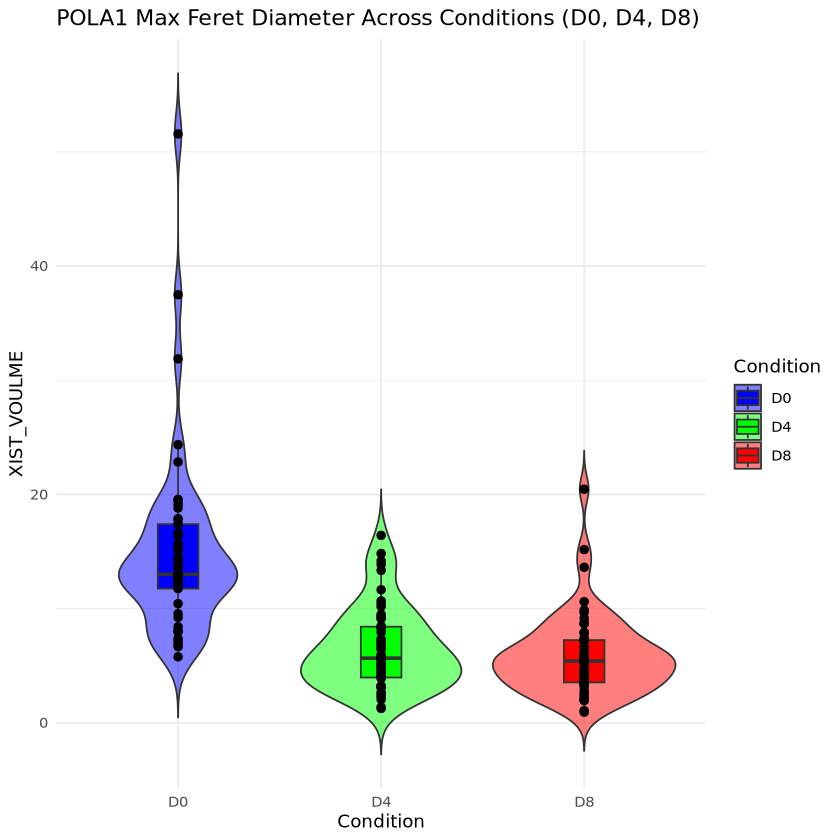

In [46]:
# Create the violin plot with the box plot overlay and individual data points

p2 <- ggplot(df_melt, aes(x = Condition, y = XIST_VOULME, fill = Condition)) +
  geom_violin(trim = FALSE, alpha = 0.5) +   # Violin plot (trim = FALSE shows full distribution)
  geom_boxplot(width = 0.2, position = position_dodge(width = 0.9), outlier.shape = NA) +  # Overlay box plot
  geom_point(position = position_dodge(width = 0.9), shape = 21, color = "black", fill = "black", size = 2) +  # Add individual data points
  labs(title = "POLA1 Max Feret Diameter Across Conditions (D0, D4, D8)", 
       x = "Condition", y = "XIST_VOULME") +
  theme_minimal() +
  scale_fill_manual(values = c("D0" = "blue", "D4" = "green", "D8" = "red"))

p2

In [12]:
output_path <- "/lustre1/project/stg_00041/Amitesh/FISH_quantification_random/"
filename <- "XIST_volume_dynamics_timecourse.pdf"

In [13]:
ggsave(file.path(output_path, filename), plot = p2, height = 8, width = 8)

Warning message:
“Removed 12 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 12 rows containing non-finite values (`stat_boxplot()`).”
Warning message:
“Removed 12 rows containing missing values (`geom_point()`).”


### Performing wilcox test on the plot by comparing D0 vs D4 and D8

Warning message:
“Removed 12 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 12 rows containing non-finite values (`stat_boxplot()`).”
Warning message:
“Removed 12 rows containing non-finite values (`stat_signif()`).”
Warning message:
“Removed 12 rows containing missing values (`geom_point()`).”


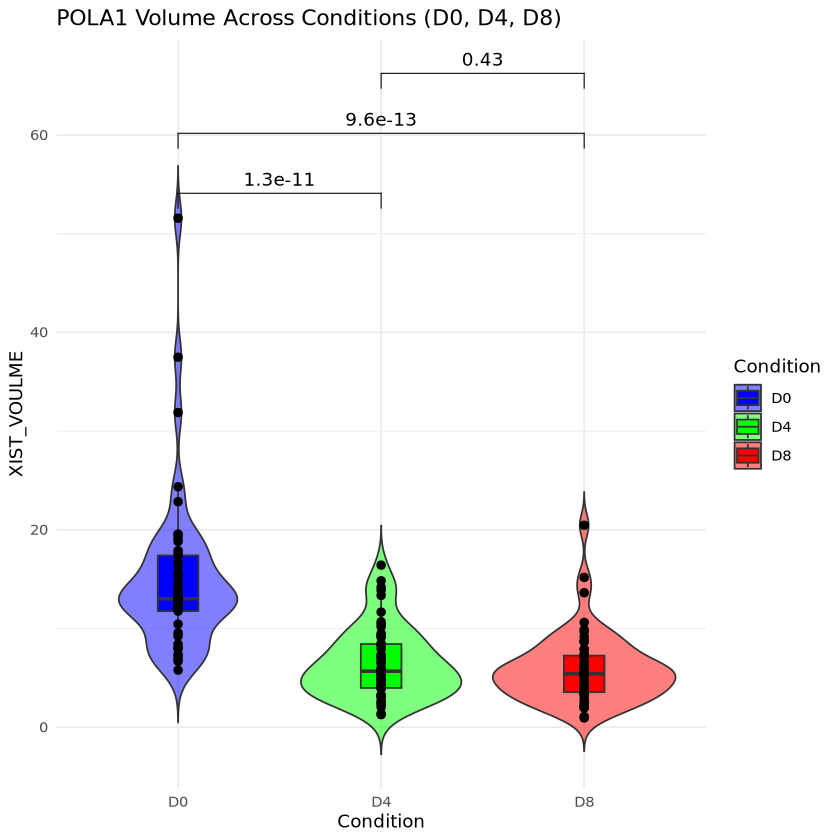

In [56]:
library(ggplot2)
library(ggpubr)

# Define pairwise comparisons
my_comparisons <- list(c("D0", "D4"), c("D0", "D8"), c("D4", "D8"))

# Create the violin + box + point + stat plot
p2 <- ggplot(df_melt, aes(x = Condition, y = XIST_VOULME, fill = Condition)) +
  geom_violin(trim = FALSE, alpha = 0.5) +
  geom_boxplot(width = 0.2, position = position_dodge(width = 0.9), outlier.shape = NA) +
  geom_point(position = position_dodge(width = 0.9), shape = 21, color = "black", fill = "black", size = 2) +
  labs(title = "POLA1 Volume Across Conditions (D0, D4, D8)", 
       x = "Condition", y = "XIST_VOULME") +
  theme_minimal() +
  scale_fill_manual(values = c("D0" = "blue", "D4" = "green", "D8" = "red")) +
  stat_compare_means(comparisons = my_comparisons, method = "wilcox.test", label = "p.format")
p2

In [57]:
output_path <- "/lustre1/project/stg_00041/Amitesh/FISH_quantification_random/"
filename <- "XIST_volume_dynamics_timecourse_with_wilcox_stat.pdf"

In [58]:
ggsave(file.path(output_path, filename), plot = p2, height = 8, width = 8)

Warning message:
“Removed 12 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 12 rows containing non-finite values (`stat_boxplot()`).”
Warning message:
“Removed 12 rows containing non-finite values (`stat_signif()`).”
Warning message:
“Removed 12 rows containing missing values (`geom_point()`).”


## Above we did for XIST volume and here we are doing for max_feret diameter of XIST

In [47]:
D0 <- c(4.590891076, 3.781442063, 7.070439745, 4.320861733, 4.503720811, 3.979324347, 7.037331966, 17.1028569, 5.889675417, 5.385685415, 5.07822235, 4.970244825, 5.518926312, 4.50210967, 21.37216415, 6.204015188, 5.117665188, 5.580997751, 9.204172016, 7.106665452, 11.46862358, 8.540937283, 4.627193532, 7.861871302, 5.824761668, 7.372796121, 5.030951314, 5.919995609, 5.820321815, 9.310975989, 5.143840499, 5.683707569, 5.539095075, 9.317246737, 4.641402314, 4.490173604, 7.462558665, 5.198874624, 5.79744163, 5.954271059, 4.026374954, 4.231073981, 4.673970597, 6.013767404, 6.391860318)
D4 <- c(4.059570424, 3.753100675, 3.559236278, 4.378614503, 3.222902051, 3.84891975, 2.645190032, 3.254348431, 2.859203226, 3.296063524, 2.383834248, 3.884039737, 3.802559819, 4.946836292, 3.279854371, 3.95792789, 5.065349161, 2.790156942, 3.107511275, 3.125269307, 5.384355345, 3.437636471, 2.68320596, 3.781737453, 2.715319039, 4.38504547, 3.231806272, 2.514874594, 5.246139039, 6.817184031, 4.674070146, 3.533009276, 2.095248751, 3.489728407, 7.701766296, 4.562257497, 3.617733456, 3.053619856, 3.905816455, 3.233849308, 3.164631005, 3.972703811, 4.3777643, 3.503108563, 4.066917785, 3.278975944, 3.739595351, 2.982245744, 2.888361934, 1.808236784, 3.771491132, 12.49843581, 3.986399511, 5.425601751, 6.602334012, 4.035303664)
D8 <- c(5.652530667, 3.394153996, 3.695764557, 4.439597467, 4.149325954, 1.660554512, 1.869734779, 3.456254322, 3.5583475, 14.67460854, 4.586493212, 6.155387438, 6.911607545, 5.352617023, 4.878834885, 4.052989801, 2.769043481, 2.095248751, 3.065384387, 4.25273614, 2.655191723, 2.424799566, 3.434766985, 7.404215547, 3.901146624, 4.91355923, 2.790156942, 3.473138086, 3.16398444, 6.928716526, 6.72711895, 4.78653528, 3.338677823, 3.158070035, 3.497183147, 3.793597377, 4.256933104, 3.067568379, 3.851649465, 3.453265569, 3.337786689, 5.468476145, 3.231403966, 2.544983405, 4.348047585, 3.189105448, 3.030599001, 6.264109037, 4.021728991, 3.180257027, 4.773596494, 3.758944422, 3.29603498, 3.642431638, 2.893606311)
max_length <- max(length(D0), length(D4), length(D8))

D0 <- c(D0, rep(NA, max_length - length(D0)))
D4 <- c(D4, rep(NA, max_length - length(D4)))
D8 <- c(D8, rep(NA, max_length - length(D8)))

df_1 <- data.frame(
  D0 = D0,
  D4 = D4,
    D8 = D8
)

In [48]:
df_1

D0,D4,D8
<dbl>,<dbl>,<dbl>
4.590891,4.059570,5.652531
3.781442,3.753101,3.394154
7.070440,3.559236,3.695765
4.320862,4.378615,4.439597
4.503721,3.222902,4.149326
3.979324,3.848920,1.660555
7.037332,2.645190,1.869735
17.102857,3.254348,3.456254
5.889675,2.859203,3.558347


In [49]:
df_melt_1 <- melt(df_1, variable.name = "Condition", value.name = "XIST_max_feret_diameter")

No id variables; using all as measure variables



In [50]:
df_melt_1


Condition,XIST_max_feret_diameter
<fct>,<dbl>
D0,4.590891
D0,3.781442
D0,7.070440
D0,4.320862
D0,4.503721
D0,3.979324
D0,7.037332
D0,17.102857
D0,5.889675


Warning message:
“Removed 12 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 12 rows containing non-finite values (`stat_boxplot()`).”
Warning message:
“Removed 12 rows containing missing values (`geom_point()`).”


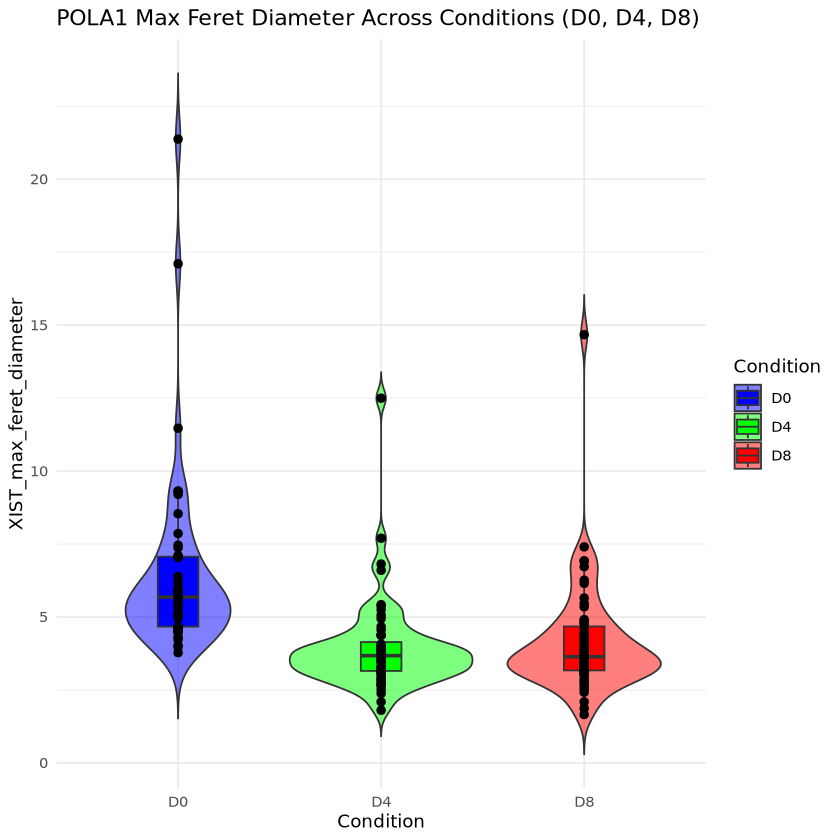

In [51]:
# Create the violin plot with the box plot overlay and individual data points
p3 <- ggplot(df_melt_1, aes(x = Condition, y = XIST_max_feret_diameter, fill = Condition)) +
  geom_violin(trim = FALSE, alpha = 0.5) +   # Violin plot (trim = FALSE shows full distribution)
  geom_boxplot(width = 0.2, position = position_dodge(width = 0.9), outlier.shape = NA) +  # Overlay box plot
  geom_point(position = position_dodge(width = 0.9), shape = 21, color = "black", fill = "black", size = 2) +  # Add individual data points
  labs(title = "POLA1 Max Feret Diameter Across Conditions (D0, D4, D8)", 
       x = "Condition", y = "XIST_max_feret_diameter") +
  theme_minimal() +
  scale_fill_manual(values = c("D0" = "blue", "D4" = "green", "D8" = "red"))

p3

In [21]:
output_path <- "/lustre1/project/stg_00041/Amitesh/FISH_quantification_random/"
filename <- "XIST_max_feret_diameter_dynamics_timecourse.pdf"

In [22]:
ggsave(file.path(output_path, filename), plot = p3, height = 8, width = 8)

Warning message:
“Removed 12 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 12 rows containing non-finite values (`stat_boxplot()`).”
Warning message:
“Removed 12 rows containing missing values (`geom_point()`).”


### Again perfroming the wilcox test by comparing between D0 vs D4 and D8 for max feret diamter

Warning message:
“Removed 12 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 12 rows containing non-finite values (`stat_boxplot()`).”
Warning message:
“Removed 12 rows containing non-finite values (`stat_signif()`).”
Warning message:
“Removed 12 rows containing missing values (`geom_point()`).”


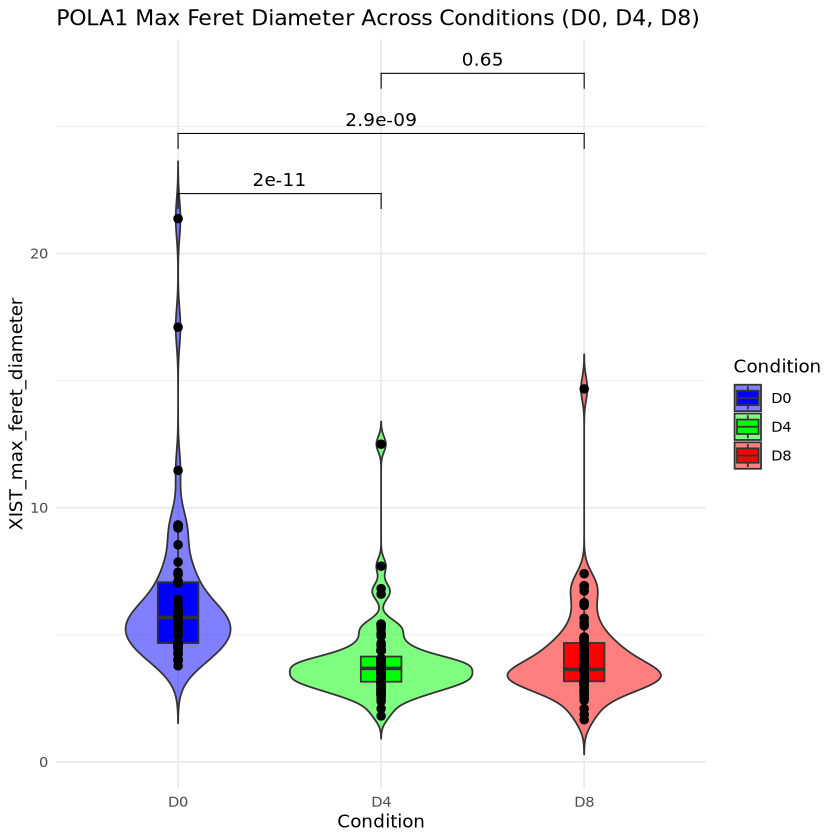

In [53]:
library(ggpubr)

# Define comparisons
my_comparisons <- list(c("D0", "D4"), c("D0", "D8"), c("D4", "D8"))

# Create plot
p3 <- ggplot(df_melt_1, aes(x = Condition, y = XIST_max_feret_diameter, fill = Condition)) +
  geom_violin(trim = FALSE, alpha = 0.5) +
  geom_boxplot(width = 0.2, position = position_dodge(width = 0.9), outlier.shape = NA) +
  geom_point(position = position_dodge(width = 0.9), shape = 21, color = "black", fill = "black", size = 2) +
  labs(title = "POLA1 Max Feret Diameter Across Conditions (D0, D4, D8)", 
       x = "Condition", y = "XIST_max_feret_diameter") +
  theme_minimal() +
  scale_fill_manual(values = c("D0" = "blue", "D4" = "green", "D8" = "red")) +
  stat_compare_means(comparisons = my_comparisons, method = "wilcox.test", label = "p.format")
p3

In [54]:
output_path <- "/lustre1/project/stg_00041/Amitesh/FISH_quantification_random/"
filename <- "XIST_max_feret_diameter_dynamics_timecourse_with_wilcox_test.pdf"

In [55]:
ggsave(file.path(output_path, filename), plot = p3, height = 8, width = 8)

Warning message:
“Removed 12 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 12 rows containing non-finite values (`stat_boxplot()`).”
Warning message:
“Removed 12 rows containing non-finite values (`stat_signif()`).”
Warning message:
“Removed 12 rows containing missing values (`geom_point()`).”


### Above we did XIST max feret and volume time-course analysis. Here we are performing POLA1 volume dynamics to know if dampening is still there for day 0 and day 4 cells

In [1]:
# Combine all your data into vectors
POLA1_Volume <- c(
  # Day 0
  0.55644, 0.907, 1.025, 0.14643, 0.64, 0.322, 0.34168, 0.32215, 0.12, 0.312, 0.16, 1.2, 0.31, 0.41001, 0.2, 0.156,
  # Day 4
  0.19524, 0.62478, 0.556, 0.33191, 0.70288, 0.1757, 0.68335, 0.8786, 0.73216, 0.8786, 0.45882, 0.56621, 0.54668,   0.21477, 0.41001, 0.45882, 0.83955, 0.62478, 0.94693, 0.31239, 0.56621
)

Condition <- rep("XIST_positive", times = length(POLA1_Volume))

Timepoint <- c(rep("Day 0", 16), rep("Day 4", 21))

# Repeat for XIST-negative
POLA1_Volume_neg <- c(
  # Day 0
  1.0348, 1.1227, 1.2398, 0.8395, 0.663, 0.429, 1.425, 1.0348, 0.4393, 0.751, 0.4, 1.8, 0.95669, 1.4643, 1.161, 0.741,
  # Day 4
  0.68335, 1.3374, 0.97622, 1.454, 1.4448, 1.054, 2.6163, 1.2593, 0.75169, 1.2593, 0.56621, 1.1129, 0.55644,
  0.40025, 0.5174, 0.77121, 1.5131, 1.5717, 1.1129, 0.47835, 0.90788
)

Condition_neg <- rep("XIST_negative", times = length(POLA1_Volume_neg))
Timepoint_neg <- c(rep("Day 0", 16), rep("Day 4", 21))

# Combine both into one data frame
df <- data.frame(
  POLA1_Volume = c(POLA1_Volume, POLA1_Volume_neg),
  Condition = c(Condition, Condition_neg),
  Timepoint = c(Timepoint, Timepoint_neg)
)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
df

POLA1_Volume,Condition,Timepoint
<dbl>,<chr>,<chr>
0.55644,XIST_positive,Day 0
0.90700,XIST_positive,Day 0
1.02500,XIST_positive,Day 0
0.14643,XIST_positive,Day 0
0.64000,XIST_positive,Day 0
0.32200,XIST_positive,Day 0
0.34168,XIST_positive,Day 0
0.32215,XIST_positive,Day 0
0.12000,XIST_positive,Day 0


Warning message in wilcox.test.default(c(1.0348, 1.1227, 1.2398, 0.8395, 0.663, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.68335, 1.3374, 0.97622, 1.454, 1.4448, :
“cannot compute exact p-value with ties”


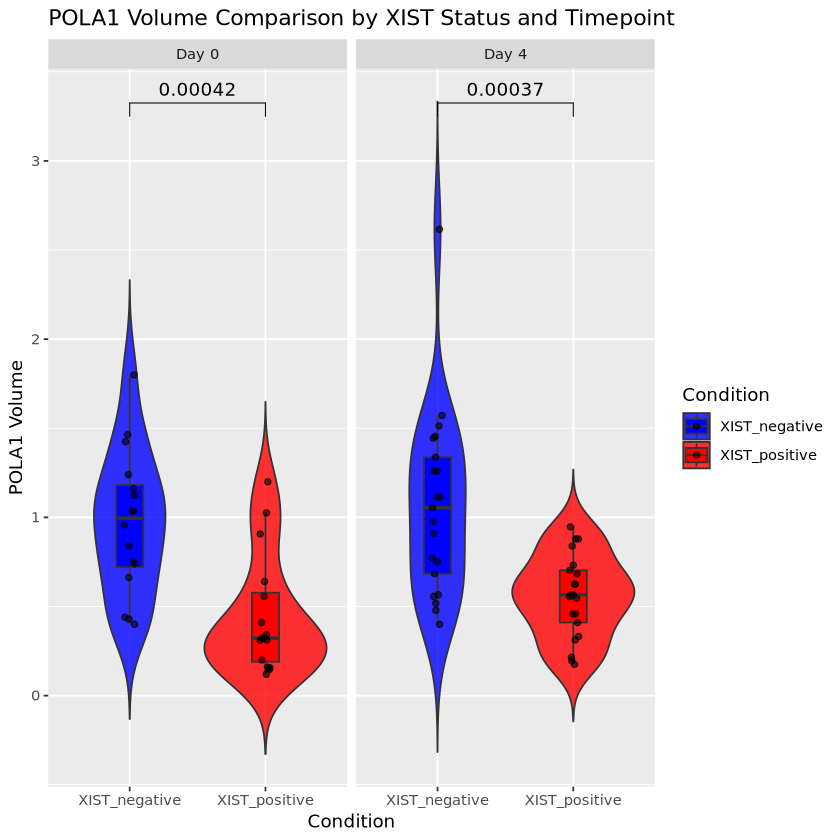

In [41]:
library(ggplot2)
library(ggpubr)

p <- ggplot(df, aes(x = Condition, y = POLA1_Volume, fill = Condition)) +
  geom_violin(trim = FALSE, alpha = 0.8) +
  geom_boxplot(width = 0.2, outlier.shape = NA) +
  geom_jitter(width = 0.04, size = 1.5, alpha = 0.6) +
  facet_wrap(~Timepoint) +
  labs(title = "POLA1 Volume Comparison by XIST Status and Timepoint",
       y = "POLA1 Volume", x = "Condition") +
  scale_fill_manual(values = c("XIST_positive" = "red", "XIST_negative" = "blue"))

p1 <- p + stat_compare_means(method = "wilcox.test", label = "p.format",
                       comparisons = list(c("XIST_negative", "XIST_positive")),
                       label.y = c(3.2, 3.2))

In [34]:
output_path <- "/lustre1/project/stg_00041/Amitesh/FISH_quantification_random/"
filename <- "POLA1_Volumeax_feret_diameter_dynamics_timecourse.pdf"

In [35]:
ggsave(file.path(output_path, filename), plot = p1, height = 8, width = 8)

Warning message in wilcox.test.default(c(1.0348, 1.1227, 1.2398, 0.8395, 0.663, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.68335, 1.3374, 0.97622, 1.454, 1.4448, :
“cannot compute exact p-value with ties”


## We repeated all the FISH experiments. Now we want to plot a bar plot by combining all three replicates. For all FISH experiments on figure 1

## THOC2

In [9]:
# Example data
data_THOC2 <- data.frame(
     Experiment = c('EXP1', 'EXP1', 'EXP1', 'EXP2', 'EXP2', 'EXP2', 'EXP3', 'EXP3', 'EXP3'),
    Cell_type = c('NAIVE', 'EXMC', 'TSC', 'NAIVE', 'EXMC', 'TSC', 'NAIVE', 'EXMC', 'TSC'),
  Monoallelic = c(21.590909, 80.597015, 79.130435, 27.737226, 57.5, 73.043478, 19.91342, 69.791667, 74.452555),
  Biallelic = c(78.40909091, 19.40298507, 20.86956522, 72.26277372, 42.5, 26.95652174, 80.08658009, 30.20833333, 25.54744526)
)

# Reshape data to long format
library(tidyr)
data_long <- data_THOC2 %>%
  pivot_longer(cols = c("Biallelic", "Monoallelic"), names_to = "ExpressionType", values_to = "Proportion")

In [10]:
print(data_long)

# A tibble: 18 × 4
   Experiment Cell_type ExpressionType Proportion
   <chr>      <chr>     <chr>               <dbl>
 1 EXP1       NAIVE     Biallelic            78.4
 2 EXP1       NAIVE     Monoallelic          21.6
 3 EXP1       EXMC      Biallelic            19.4
 4 EXP1       EXMC      Monoallelic          80.6
 5 EXP1       TSC       Biallelic            20.9
 6 EXP1       TSC       Monoallelic          79.1
 7 EXP2       NAIVE     Biallelic            72.3
 8 EXP2       NAIVE     Monoallelic          27.7
 9 EXP2       EXMC      Biallelic            42.5
10 EXP2       EXMC      Monoallelic          57.5
11 EXP2       TSC       Biallelic            27.0
12 EXP2       TSC       Monoallelic          73.0
13 EXP3       NAIVE     Biallelic            80.1
14 EXP3       NAIVE     Monoallelic          19.9
15 EXP3       EXMC      Biallelic            30.2
16 EXP3       EXMC      Monoallelic          69.8
17 EXP3       TSC       Biallelic            25.5
18 EXP3       TSC       Monoall

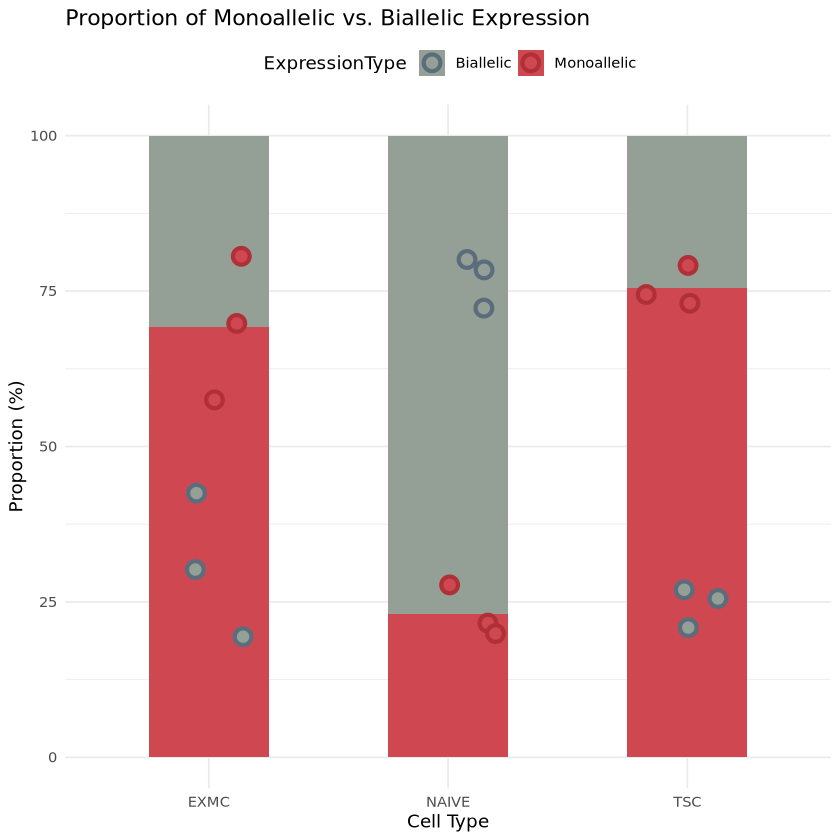

In [17]:
# Custom color palette for bars
bi_color <- "#94a096"
mono_color <- "#ce4751"

# New color palette for dots (distinct but corresponding)
bi_dot_color <- "#5b6d7c"  # Darker shade of bi_color
mono_dot_color <- "#b03038"  # Darker shade of mono_color

# Plot with stacked bars and bold dots for individual experiments
p_THOC2 <- ggplot(data_long, aes(x = Cell_type, y = Proportion, fill = ExpressionType)) +
  geom_bar(stat = "summary", fun = "mean", position = "stack", width = 0.5) +  # Bars remain the same
  geom_point(aes(x = Cell_type, y = Proportion, color = ExpressionType),  # Different colors for dots
             position = position_jitter(width = 0.2, height = 0), 
             size = 3.5, shape = 21, stroke = 1.8) +  # Bold dots with larger size and stroke
  labs(title = "Proportion of Monoallelic vs. Biallelic Expression",
       x = "Cell Type",
       y = "Proportion (%)") +
  scale_fill_manual(values = c("Monoallelic" = mono_color, "Biallelic" = bi_color)) +  # Keep bar colors
  scale_color_manual(values = c("Monoallelic" = mono_dot_color, "Biallelic" = bi_dot_color)) +  # Different dot colors
  theme_minimal() +
  theme(legend.position = "top")

p_THOC2

In [18]:
output_path <- "/lustre1/project/stg_00041/Amitesh/FISH_quantification_random/"
filename <- "THOC2_with_individual_experiments.pdf"

In [19]:
ggsave(file.path(output_path, filename), plot = p_THOC2, height = 8, width = 8)

## HUWE1

In [23]:
data_HUWE1 <- data.frame(
     Experiment = c('EXP1', 'EXP1', 'EXP1', 'EXP2', 'EXP2', 'EXP2', 'EXP3', 'EXP3', 'EXP3'),
    Cell_type = c('NAIVE', 'EXMC', 'TSC', 'NAIVE', 'EXMC', 'TSC', 'NAIVE', 'EXMC', 'TSC'),
  Monoallelic = c(19.13580247, 90.26548673, 64.56692913, 15.46391753, 87.35632184, 66.12903226, 14.87603306, 77.5862069, 67.32673267),
  Biallelic = c(80.86419753, 9.734513274, 35.43307087, 84.53608247, 12.64367816, 33.87096774, 85.12396694, 22.4137931, 32.67326733)
)

# Reshape data to long format
library(tidyr)
data_long_HUWE1 <- data_HUWE1 %>%
  pivot_longer(cols = c("Biallelic", "Monoallelic"), names_to = "ExpressionType", values_to = "Proportion")

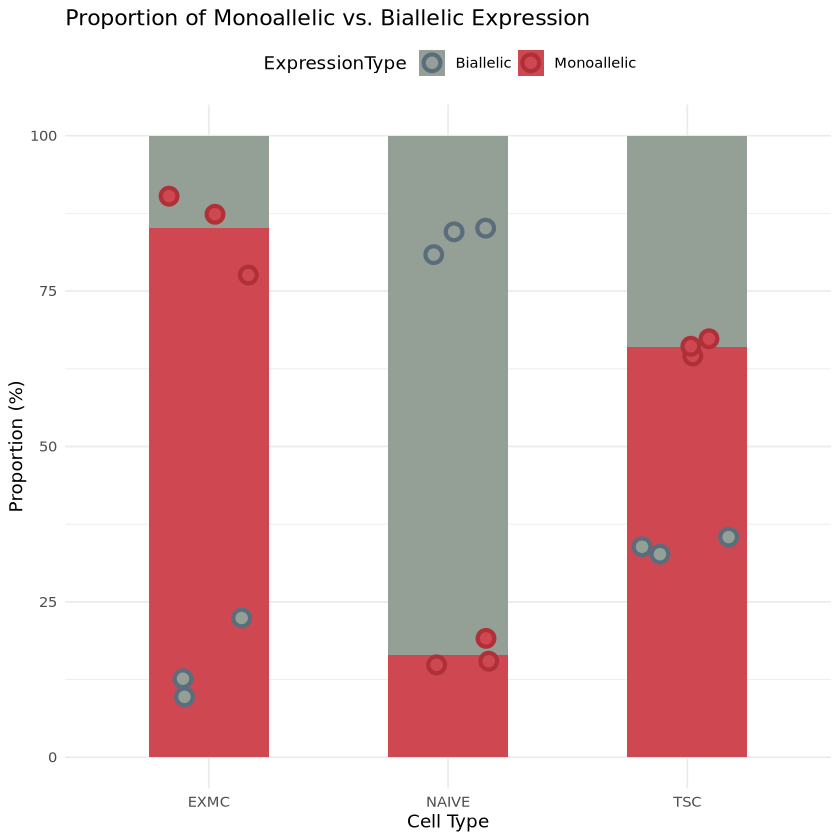

In [24]:
# Custom color palette for bars
bi_color <- "#94a096"
mono_color <- "#ce4751"

# New color palette for dots (distinct but corresponding)
bi_dot_color <- "#5b6d7c"  # Darker shade of bi_color
mono_dot_color <- "#b03038"  # Darker shade of mono_color

# Plot with stacked bars and bold dots for individual experiments
p_HUWE1 <- ggplot(data_long_HUWE1, aes(x = Cell_type, y = Proportion, fill = ExpressionType)) +
  geom_bar(stat = "summary", fun = "mean", position = "stack", width = 0.5) +  # Bars remain the same
  geom_point(aes(x = Cell_type, y = Proportion, color = ExpressionType),  # Different colors for dots
             position = position_jitter(width = 0.2, height = 0), 
             size = 3.5, shape = 21, stroke = 1.8) +  # Bold dots with larger size and stroke
  labs(title = "Proportion of Monoallelic vs. Biallelic Expression",
       x = "Cell Type",
       y = "Proportion (%)") +
  scale_fill_manual(values = c("Monoallelic" = mono_color, "Biallelic" = bi_color)) +  # Keep bar colors
  scale_color_manual(values = c("Monoallelic" = mono_dot_color, "Biallelic" = bi_dot_color)) +  # Different dot colors
  theme_minimal() +
  theme(legend.position = "top")

p_HUWE1

In [25]:
output_path <- "/lustre1/project/stg_00041/Amitesh/FISH_quantification_random/"
filename <- "HUWE1_with_individual_experiments.pdf"

In [26]:
ggsave(file.path(output_path, filename), plot = p_HUWE1, height = 8, width = 8)

## POLA1

In [27]:
# Example data
data_POLA1 <- data.frame(
     Experiment = c('EXP1', 'EXP1', 'EXP1', 'EXP2', 'EXP2', 'EXP2', 'EXP3', 'EXP3', 'EXP3'),
    Cell_type = c('NAIVE', 'EXMC', 'TSC', 'NAIVE', 'EXMC', 'TSC', 'NAIVE', 'EXMC', 'TSC'),
  Monoallelic = c(15.43209877, 96.49122807, 86.75496689, 31.2, 94.64285714, 86.20689655, 12.08791209, 97.72727273, 86.31578947),
  Biallelic = c(84.56790123, 3.50877193, 13.24503311, 68.8, 5.357142857, 13.79310345, 87.91208791, 2.272727273, 13.68421053)
)

# Reshape data to long format
library(tidyr)
data_long_POLA1 <- data_POLA1 %>%
  pivot_longer(cols = c("Biallelic", "Monoallelic"), names_to = "ExpressionType", values_to = "Proportion")

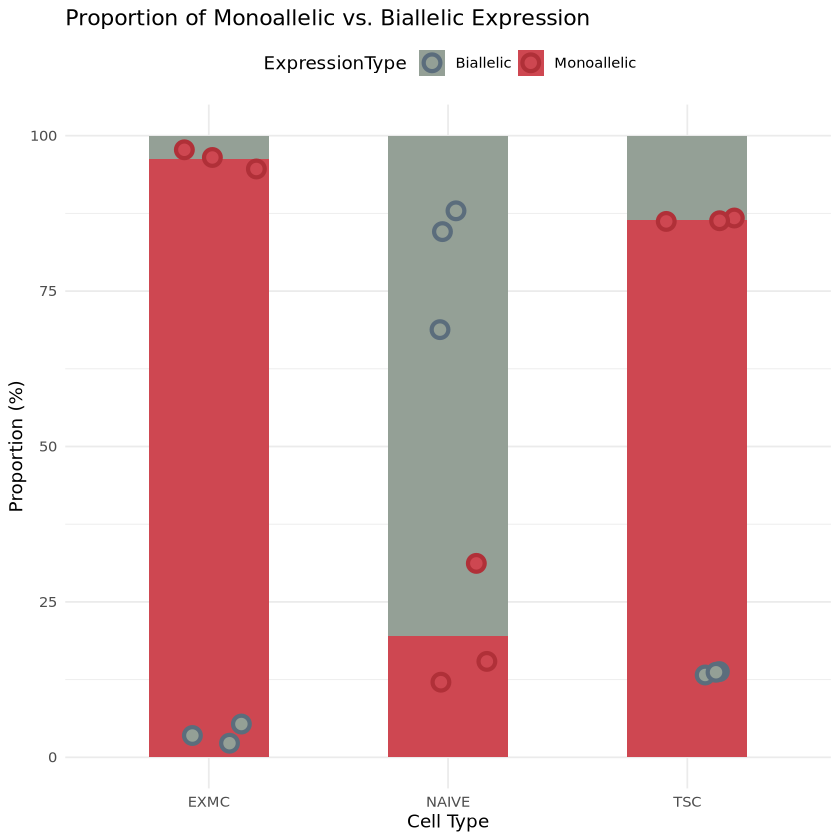

In [28]:
# Custom color palette for bars
bi_color <- "#94a096"
mono_color <- "#ce4751"

# New color palette for dots (distinct but corresponding)
bi_dot_color <- "#5b6d7c"  # Darker shade of bi_color
mono_dot_color <- "#b03038"  # Darker shade of mono_color

# Plot with stacked bars and bold dots for individual experiments
p_POLA1 <- ggplot(data_long_POLA1, aes(x = Cell_type, y = Proportion, fill = ExpressionType)) +
  geom_bar(stat = "summary", fun = "mean", position = "stack", width = 0.5) +  # Bars remain the same
  geom_point(aes(x = Cell_type, y = Proportion, color = ExpressionType),  # Different colors for dots
             position = position_jitter(width = 0.2, height = 0), 
             size = 3.5, shape = 21, stroke = 1.8) +  # Bold dots with larger size and stroke
  labs(title = "Proportion of Monoallelic vs. Biallelic Expression",
       x = "Cell Type",
       y = "Proportion (%)") +
  scale_fill_manual(values = c("Monoallelic" = mono_color, "Biallelic" = bi_color)) +  # Keep bar colors
  scale_color_manual(values = c("Monoallelic" = mono_dot_color, "Biallelic" = bi_dot_color)) +  # Different dot colors
  theme_minimal() +
  theme(legend.position = "top")

p_POLA1

In [29]:
output_path <- "/lustre1/project/stg_00041/Amitesh/FISH_quantification_random/"
filename <- "POLA1_with_individual_experiments.pdf"

In [30]:
ggsave(file.path(output_path, filename), plot = p_POLA1, height = 8, width = 8)

## XIST+POLA1

In [31]:
# Example data
data_XIST_POLA1 <- data.frame(
     Experiment = c('EXP1', 'EXP1', 'EXP1', 'EXP2', 'EXP2', 'EXP2', 'EXP3', 'EXP3', 'EXP3'),
    Cell_type = c('NAIVE', 'EXMC', 'TSC', 'NAIVE', 'EXMC', 'TSC', 'NAIVE', 'EXMC', 'TSC'),
  Monoallelic = c(10.22727273, 89.10891089, 87.37864078, 20.45454545, 98.82352941, 97.22222222, 12.30769231, 95.77464789, 90.51724138),
  Biallelic = c(89.77272727, 10.89108911, 12.62135922, 79.54545455, 1.176470588, 2.777777778, 87.69230769, 4.225352113, 9.482758621)
)

# Reshape data to long format
library(tidyr)
data_long_XIST_POLA1 <- data_XIST_POLA1 %>%
  pivot_longer(cols = c("Biallelic", "Monoallelic"), names_to = "ExpressionType", values_to = "Proportion")

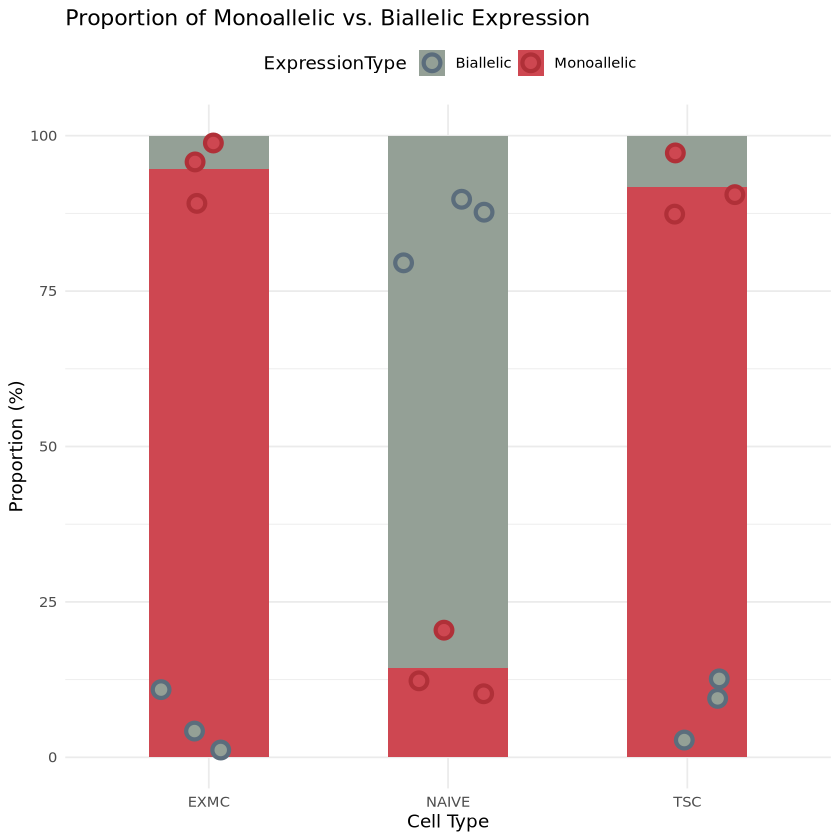

In [32]:
# Custom color palette for bars
bi_color <- "#94a096"
mono_color <- "#ce4751"

# New color palette for dots (distinct but corresponding)
bi_dot_color <- "#5b6d7c"  # Darker shade of bi_color
mono_dot_color <- "#b03038"  # Darker shade of mono_color

# Plot with stacked bars and bold dots for individual experiments
p_XIST_POLA1 <- ggplot(data_long_XIST_POLA1, aes(x = Cell_type, y = Proportion, fill = ExpressionType)) +
  geom_bar(stat = "summary", fun = "mean", position = "stack", width = 0.5) +  # Bars remain the same
  geom_point(aes(x = Cell_type, y = Proportion, color = ExpressionType),  # Different colors for dots
             position = position_jitter(width = 0.2, height = 0), 
             size = 3.5, shape = 21, stroke = 1.8) +  # Bold dots with larger size and stroke
  labs(title = "Proportion of Monoallelic vs. Biallelic Expression",
       x = "Cell Type",
       y = "Proportion (%)") +
  scale_fill_manual(values = c("Monoallelic" = mono_color, "Biallelic" = bi_color)) +  # Keep bar colors
  scale_color_manual(values = c("Monoallelic" = mono_dot_color, "Biallelic" = bi_dot_color)) +  # Different dot colors
  theme_minimal() +
  theme(legend.position = "top")

p_XIST_POLA1

In [33]:
output_path <- "/lustre1/project/stg_00041/Amitesh/FISH_quantification_random/"
filename <- "XIST_POLA1_with_individual_experiments.pdf"

In [34]:
ggsave(file.path(output_path, filename), plot = p_XIST_POLA1, height = 8, width = 8)

## XIST

In [40]:
# Example data
data_XIST <- data.frame(
     Experiment = c('EXP1', 'EXP1', 'EXP1', 'EXP2', 'EXP2', 'EXP2', 'EXP3', 'EXP3', 'EXP3'),
    Cell_type = c('NAIVE', 'EXMC', 'TSC', 'NAIVE', 'EXMC', 'TSC', 'NAIVE', 'EXMC', 'TSC'),
  Monoallelic = c(97.91666667, 100, 100, 100, 100, 100, 99.43181818, 100, 100),
  Biallelic = c(2.083333333, 0, 0, 0, 0, 0, 0.5681818182, 0, 0)
)

# Reshape data to long format
library(tidyr)
data_long_XIST <- data_XIST %>%
  pivot_longer(cols = c("Biallelic", "Monoallelic"), names_to = "ExpressionType", values_to = "Proportion")

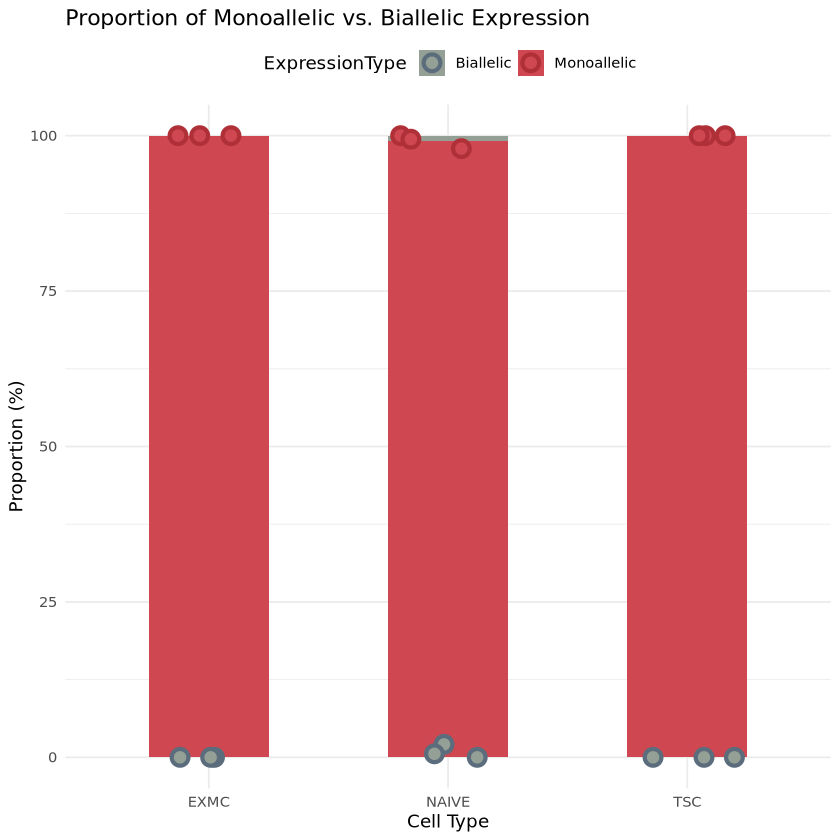

In [44]:
# Load necessary libraries
library(ggplot2)

# Custom color palette for bars
bi_color <- "#94a096"
mono_color <- "#ce4751"

# New color palette for dots (distinct but corresponding)
bi_dot_color <- "#5b6d7c"  # Darker shade of bi_color
mono_dot_color <- "#b03038"  # Darker shade of mono_color

# Plot with stacked bars and bold dots for individual experiments
p_XIST <- ggplot(data_long_XIST, aes(x = Cell_type, y = Proportion, fill = ExpressionType)) +
  geom_bar(stat = "summary", fun = "mean", position = "stack", width = 0.5) +  # Bars remain the same
  geom_point(aes(x = Cell_type, y = Proportion, color = ExpressionType),  # Different colors for dots
             position = position_jitter(width = 0.2, height = 0), 
             size = 3.5, shape = 21, stroke = 1.8) +  # Bold dots with larger size and stroke
  labs(title = "Proportion of Monoallelic vs. Biallelic Expression",
       x = "Cell Type",
       y = "Proportion (%)") +
  scale_fill_manual(values = c("Monoallelic" = mono_color, "Biallelic" = bi_color)) +  # Keep bar colors
  scale_color_manual(values = c("Monoallelic" = mono_dot_color, "Biallelic" = bi_dot_color)) +  # Different dot colors
  theme_minimal() +
  theme(legend.position = "top")

p_XIST

In [47]:
output_path <- "/lustre1/project/stg_00041/Amitesh/FISH_quantification_random/"
filename <- "1_with_individual_experiments.pdf"

In [48]:
ggsave(file.path(output_path, filename), plot = p_XIST, height = 8, width = 8)

## ATRX

In [49]:
# Example data
data_ATRX <- data.frame(
     Experiment = c('EXP1', 'EXP1', 'EXP1', 'EXP2', 'EXP2', 'EXP2', 'EXP3', 'EXP3', 'EXP3'),
    Cell_type = c('NAIVE', 'EXMC', 'TSC', 'NAIVE', 'EXMC', 'TSC', 'NAIVE', 'EXMC', 'TSC'),
  Monoallelic = c(16.66666667, 78.83211679, 74.07407407, 20, 78.26086957, 82.65306122, 7.407407407, 75.34246575, 78.04878049),
  Biallelic = c(83.33333333, 21.16788321, 25.92592593, 80, 21.73913043, 17.34693878, 92.59259259, 24.65753425, 21.95121951)
)

# Reshape data to long format
library(tidyr)
data_long_ATRX <- data_ATRX %>%
  pivot_longer(cols = c("Biallelic", "Monoallelic"), names_to = "ExpressionType", values_to = "Proportion")

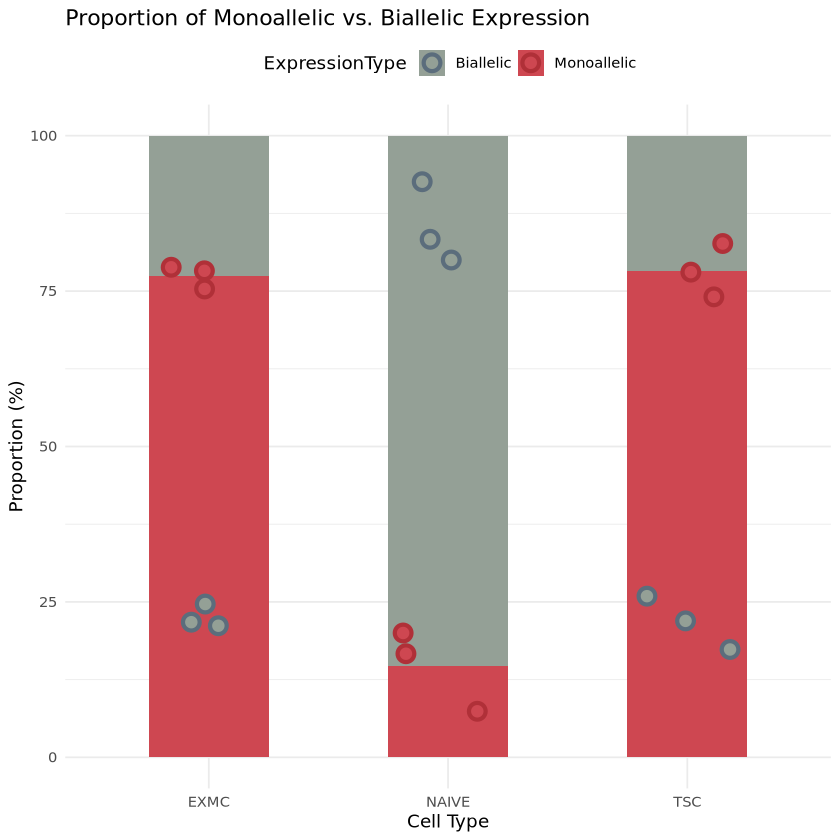

In [50]:
# Load necessary libraries
library(ggplot2)

# Custom color palette for bars
bi_color <- "#94a096"
mono_color <- "#ce4751"

# New color palette for dots (distinct but corresponding)
bi_dot_color <- "#5b6d7c"  # Darker shade of bi_color
mono_dot_color <- "#b03038"  # Darker shade of mono_color

# Plot with stacked bars and bold dots for individual experiments
p_ATRX <- ggplot(data_long_ATRX, aes(x = Cell_type, y = Proportion, fill = ExpressionType)) +
  geom_bar(stat = "summary", fun = "mean", position = "stack", width = 0.5) +  # Bars remain the same
  geom_point(aes(x = Cell_type, y = Proportion, color = ExpressionType),  # Different colors for dots
             position = position_jitter(width = 0.2, height = 0), 
             size = 3.5, shape = 21, stroke = 1.8) +  # Bold dots with larger size and stroke
  labs(title = "Proportion of Monoallelic vs. Biallelic Expression",
       x = "Cell Type",
       y = "Proportion (%)") +
  scale_fill_manual(values = c("Monoallelic" = mono_color, "Biallelic" = bi_color)) +  # Keep bar colors
  scale_color_manual(values = c("Monoallelic" = mono_dot_color, "Biallelic" = bi_dot_color)) +  # Different dot colors
  theme_minimal() +
  theme(legend.position = "top")

p_ATRX

In [51]:
output_path <- "/lustre1/project/stg_00041/Amitesh/FISH_quantification_random/"
filename <- "ATRX_with_individual_experiments.pdf"

In [52]:
ggsave(file.path(output_path, filename), plot = p_ATRX, height = 8, width = 8)

## GATA3-POLA1 timecourse IF-FISH for figure 3

In [157]:
# Example data
data_GAT3_POLA1 <- data.frame(
     Experiment = c('EXP1', 'EXP1', 'EXP1', 'EXP1', 'EXP1', 'EXP2', 'EXP2', 'EXP2', 'EXP2', 'EXP2', 'EXP3', 'EXP3', 'EXP3', 'EXP3', 'EXP3'),
    Cell_type = c('D8', 'D10', 'D12', 'D14', 'D16', 'D8', 'D10', 'D12', 'D14', 'D16', 'D8', 'D10', 'D12', 'D14', 'D16'),
  Monoallelic = c(60.60606061, 64.54545455, 85, 85.71428571, 75.2688172, 79.3814433, 84.81012658, 71.92982456, 80.46875, 89.09090909, 66.66666667, 85.96491228, 81.72043011, 83.33333333, 85.45454545),
  Biallelic = c(39.39393939, 35.45454545, 15, 14.28571429, 24.7311828, 20.6185567, 15.18987342, 28.07017544, 19.53125, 10.90909091, 33.33333333, 14.03508772, 18.27956989, 16.66666667, 14.54545455)
)

# Reshape data to long format
library(tidyr)
data_long_GAT3_POLA1 <- data_GAT3_POLA1 %>%
  pivot_longer(cols = c("Biallelic", "Monoallelic"), names_to = "ExpressionType", values_to = "Proportion")

In [158]:
#view(data_long_GAT3_POLA1)
#tail(data_long_GAT3_POLA1)
#dim(data_long_GAT3_POLA1)
head(data_long_GAT3_POLA1, 30)

Experiment,Cell_type,ExpressionType,Proportion
<chr>,<chr>,<chr>,<dbl>
EXP1,D8,Biallelic,39.39394
EXP1,D8,Monoallelic,60.60606
EXP1,D10,Biallelic,35.45455
EXP1,D10,Monoallelic,64.54545
EXP1,D12,Biallelic,15.00000
EXP1,D12,Monoallelic,85.00000
EXP1,D14,Biallelic,14.28571
EXP1,D14,Monoallelic,85.71429
EXP1,D16,Biallelic,24.73118


In [159]:
# Set factor levels for Cell_type in the desired order
data_long_GAT3_POLA1$Cell_type <- factor(data_long_GAT3_POLA1$Cell_type, levels = c("D8", "D10", "D12", "D14", "D16"))

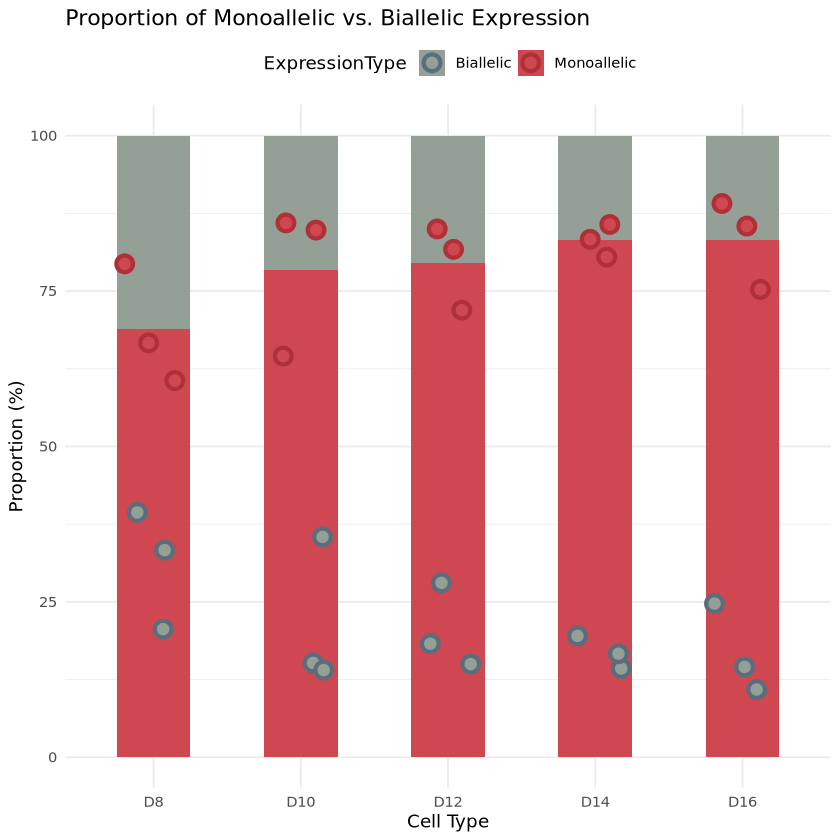

In [160]:
# Load necessary libraries
library(ggplot2)

# Custom color palette for bars
bi_color <- "#94a096"
mono_color <- "#ce4751"

# New color palette for dots (distinct but corresponding)
bi_dot_color <- "#5b6d7c"  # Darker shade of bi_color
mono_dot_color <- "#b03038"  # Darker shade of mono_color

# Plot with stacked bars and bold dots for individual experiments
p_GAT3_POLA1 <- ggplot(data_long_GAT3_POLA1, aes(x = Cell_type, y = Proportion, fill = ExpressionType)) +
  geom_bar(stat = "summary", fun = "mean", position = "stack", width = 0.5) +  # Bars remain the same
  geom_point(aes(x = Cell_type, y = Proportion, color = ExpressionType),  # Different colors for dots
             position = position_jitter(width = 0.2, height = 0), 
             size = 3.5, shape = 21, stroke = 1.8) +  # Bold dots with larger size and stroke
  labs(title = "Proportion of Monoallelic vs. Biallelic Expression",
       x = "Cell Type",
       y = "Proportion (%)") +
  scale_fill_manual(values = c("Monoallelic" = mono_color, "Biallelic" = bi_color)) +  # Keep bar colors
  scale_color_manual(values = c("Monoallelic" = mono_dot_color, "Biallelic" = bi_dot_color)) +  # Different dot colors
  theme_minimal() +
  theme(legend.position = "top")

p_GAT3_POLA1

In [161]:
output_path <- "/lustre1/project/stg_00041/Amitesh/FISH_quantification_random/"
filename <- "GATA3_POLA1_with_individual_experiments.pdf"

In [162]:
ggsave(file.path(output_path, filename), plot = p_GAT3_POLA1, height = 8, width = 8)

## VIM-POLA1 timecourse

In [66]:
# Example data
data_VIM_POLA1 <- data.frame(
     Experiment = c('EXP1', 'EXP1', 'EXP1', 'EXP1', 'EXP1', 'EXP2', 'EXP2', 'EXP2', 'EXP2', 'EXP2', 'EXP3', 'EXP3', 'EXP3', 'EXP3', 'EXP3'),
    Cell_type = c('D8', 'D10', 'D12', 'D14', 'D16', 'D8', 'D10', 'D12', 'D14', 'D16', 'D8', 'D10', 'D12', 'D14', 'D16'),
  Monoallelic = c(55.93220339, 67.5, 72.36842105, 80.48780488, 81.25, 79.31034483, 81.3559322, 71.69811321, 73.52941176, 80, 63.76811594, 79.54545455, 82.92682927, 94.33962264, 78.20512821),
  Biallelic = c(44.06779661, 32.5, 27.63157895, 19.51219512, 18.75, 20.68965517, 18.6440678, 28.30188679, 26.47058824, 20, 36.23188406, 20.45454545, 17.07317073, 5.660377358, 21.79487179)
)
# Reshape data to long format
library(tidyr)
data_long_VIM_POLA1 <- data_VIM_POLA1 %>%
  pivot_longer(cols = c("Biallelic", "Monoallelic"), names_to = "ExpressionType", values_to = "Proportion")

In [67]:
#view(data_long_GAT3_POLA1)
#tail(data_long_GAT3_POLA1)
#dim(data_long_GAT3_POLA1)
head(data_long_VIM_POLA1, 30)

Experiment,Cell_type,ExpressionType,Proportion
<chr>,<chr>,<chr>,<dbl>
EXP1,D8,Biallelic,44.067797
EXP1,D8,Monoallelic,55.932203
EXP1,D10,Biallelic,32.500000
EXP1,D10,Monoallelic,67.500000
EXP1,D12,Biallelic,27.631579
EXP1,D12,Monoallelic,72.368421
EXP1,D14,Biallelic,19.512195
EXP1,D14,Monoallelic,80.487805
EXP1,D16,Biallelic,18.750000


In [163]:
# Set factor levels for Cell_type in the desired order
data_long_VIM_POLA1$Cell_type <- factor(data_long_VIM_POLA1$Cell_type, levels = c("D8", "D10", "D12", "D14", "D16"))

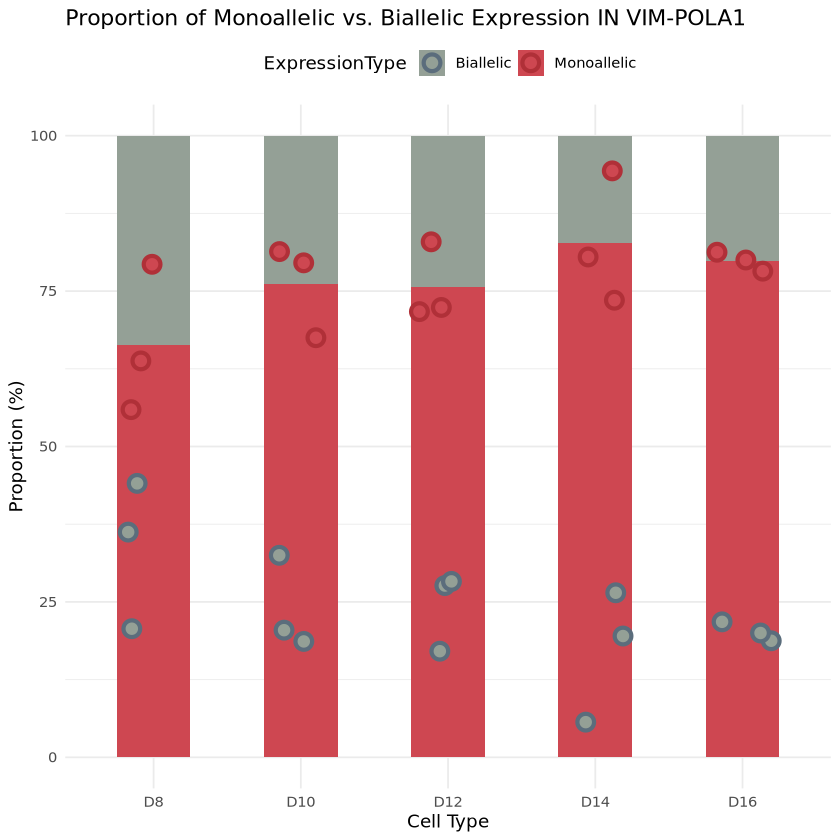

In [164]:
# Load necessary libraries
library(ggplot2)

# Custom color palette for bars
bi_color <- "#94a096"
mono_color <- "#ce4751"

# New color palette for dots (distinct but corresponding)
bi_dot_color <- "#5b6d7c"  # Darker shade of bi_color
mono_dot_color <- "#b03038"  # Darker shade of mono_color

# Plot with stacked bars and bold dots for individual experiments
p_VIM_POLA1 <- ggplot(data_long_VIM_POLA1, aes(x = Cell_type, y = Proportion, fill = ExpressionType)) +
  geom_bar(stat = "summary", fun = "mean", position = "stack", width = 0.5) +  # Bars remain the same
  geom_point(aes(x = Cell_type, y = Proportion, color = ExpressionType),  # Different colors for dots
             position = position_jitter(width = 0.2, height = 0), 
             size = 3.5, shape = 21, stroke = 1.8) +  # Bold dots with larger size and stroke
  labs(title = "Proportion of Monoallelic vs. Biallelic Expression IN VIM-POLA1",
       x = "Cell Type",
       y = "Proportion (%)") +
  scale_fill_manual(values = c("Monoallelic" = mono_color, "Biallelic" = bi_color)) +  # Keep bar colors
  scale_color_manual(values = c("Monoallelic" = mono_dot_color, "Biallelic" = bi_dot_color)) +  # Different dot colors
  theme_minimal() +
  theme(legend.position = "top")

p_VIM_POLA1

In [165]:
output_path <- "/lustre1/project/stg_00041/Amitesh/FISH_quantification_random/"
filename <- "VIM_POLA1_with_individual_experiments.pdf"

In [166]:
ggsave(file.path(output_path, filename), plot = p_VIM_POLA1, height = 8, width = 8)

## POLA1 timecourse

In [80]:
# Example data
data_POLA1 <- data.frame(
     Experiment = c('EXP1', 'EXP1', 'EXP1', 'EXP1', 'EXP1', 'EXP1', 'EXP1', 'EXP2', 'EXP2', 'EXP2', 'EXP2', 'EXP2', 'EXP2', 'EXP2', 'EXP3', 'EXP3', 'EXP3', 'EXP3', 'EXP3', 'EXP3', 'EXP3'),
    Cell_type = c('D0', 'D4', 'D8', 'D10', 'D12', 'D14', 'D16', 'D0', 'D4', 'D8', 'D10', 'D12', 'D14', 'D16', 'D0', 'D4', 'D8', 'D10', 'D12', 'D14', 'D16'),
  Monoallelic = c(23.65591398, 21.72131148, 53.65853659, 75.20661157, 75.2, 78.47222222, 81.64556962, 18.24324324, 15.92920354, 69.8630137, 75.47169811, 70.50359712, 77.48691099, 76.92307692, 34.375, 16.21621622, 66.10169492, 89.70588235, 79.61165049, 94.14893617, 83.16831683),
  Biallelic = c(76.34408602, 78.27868852, 46.34146341, 24.79338843, 24.8, 21.52777778, 18.35443038, 81.75675676, 84.07079646, 30.1369863, 24.52830189, 29.49640288, 22.51308901, 23.07692308, 65.625, 83.78378378, 33.89830508, 10.29411765, 20.38834951, 5.85106383, 16.83168317)
    )
# Reshape data to long format
library(tidyr)
data_long_POLA1 <- data_POLA1 %>%
  pivot_longer(cols = c("Biallelic", "Monoallelic"), names_to = "ExpressionType", values_to = "Proportion")

In [81]:
#view(data_long_GAT3_POLA1)
#tail(data_long_GAT3_POLA1)
dim(data_long_POLA1)
head(data_long_POLA1, 50)

[1] 42  4

Experiment,Cell_type,ExpressionType,Proportion
<chr>,<chr>,<chr>,<dbl>
EXP1,D0,Biallelic,76.344086
EXP1,D0,Monoallelic,23.655914
EXP1,D4,Biallelic,78.278689
EXP1,D4,Monoallelic,21.721311
EXP1,D8,Biallelic,46.341463
EXP1,D8,Monoallelic,53.658537
EXP1,D10,Biallelic,24.793388
EXP1,D10,Monoallelic,75.206612
EXP1,D12,Biallelic,24.800000


In [82]:
# Set factor levels for Cell_type in the desired order
data_long_POLA1$Cell_type <- factor(data_long_POLA1$Cell_type, levels = c("D0", "D4", "D8", "D10", "D12", "D14", "D16"))

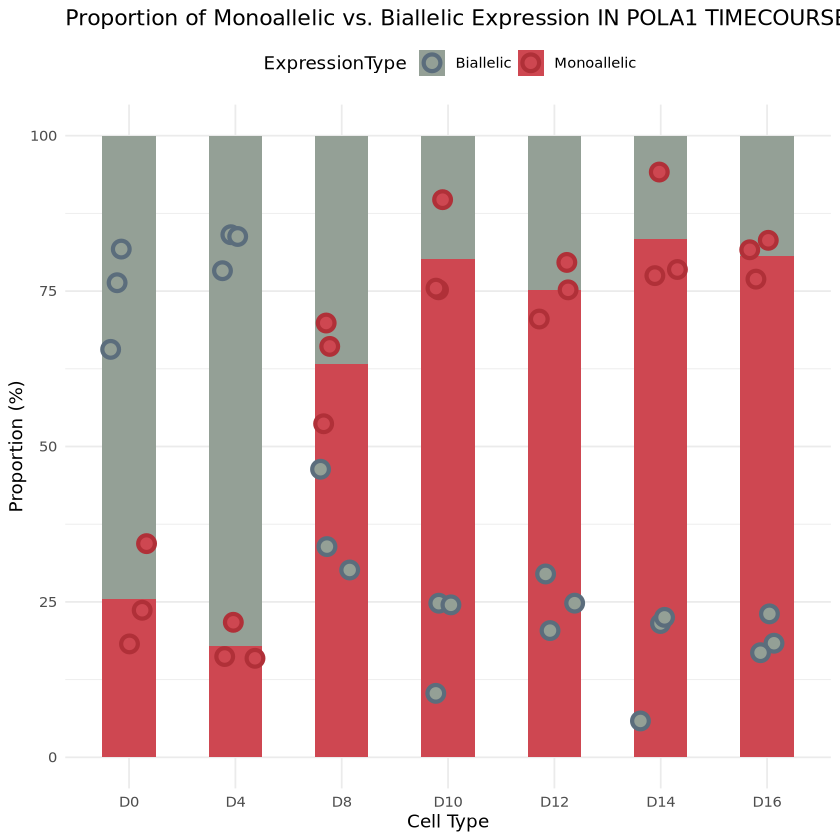

In [83]:
# Load necessary libraries
library(ggplot2)

# Custom color palette for bars
bi_color <- "#94a096"
mono_color <- "#ce4751"

# New color palette for dots (distinct but corresponding)
bi_dot_color <- "#5b6d7c"  # Darker shade of bi_color
mono_dot_color <- "#b03038"  # Darker shade of mono_color

# Plot with stacked bars and bold dots for individual experiments
p_POLA1 <- ggplot(data_long_POLA1, aes(x = Cell_type, y = Proportion, fill = ExpressionType)) +
  geom_bar(stat = "summary", fun = "mean", position = "stack", width = 0.5) +  # Bars remain the same
  geom_point(aes(x = Cell_type, y = Proportion, color = ExpressionType),  # Different colors for dots
             position = position_jitter(width = 0.2, height = 0), 
             size = 3.5, shape = 21, stroke = 1.8) +  # Bold dots with larger size and stroke
  labs(title = "Proportion of Monoallelic vs. Biallelic Expression IN POLA1 TIMECOURSE",
       x = "Cell Type",
       y = "Proportion (%)") +
  scale_fill_manual(values = c("Monoallelic" = mono_color, "Biallelic" = bi_color)) +  # Keep bar colors
  scale_color_manual(values = c("Monoallelic" = mono_dot_color, "Biallelic" = bi_dot_color)) +  # Different dot colors
  theme_minimal() +
  theme(legend.position = "top")

p_POLA1

In [167]:
output_path <- "/lustre1/project/stg_00041/Amitesh/FISH_quantification_random/"
filename <- "POLA1_TIMECOURSE_with_individual_experiments.pdf"

In [168]:
ggsave(file.path(output_path, filename), plot = p_POLA1, height = 8, width = 8)

## Plotting XIST positive allele vs negative of POLA1 volumne to show the XIST expressed allele undergoes dampening

No id variables; using all as measure variables



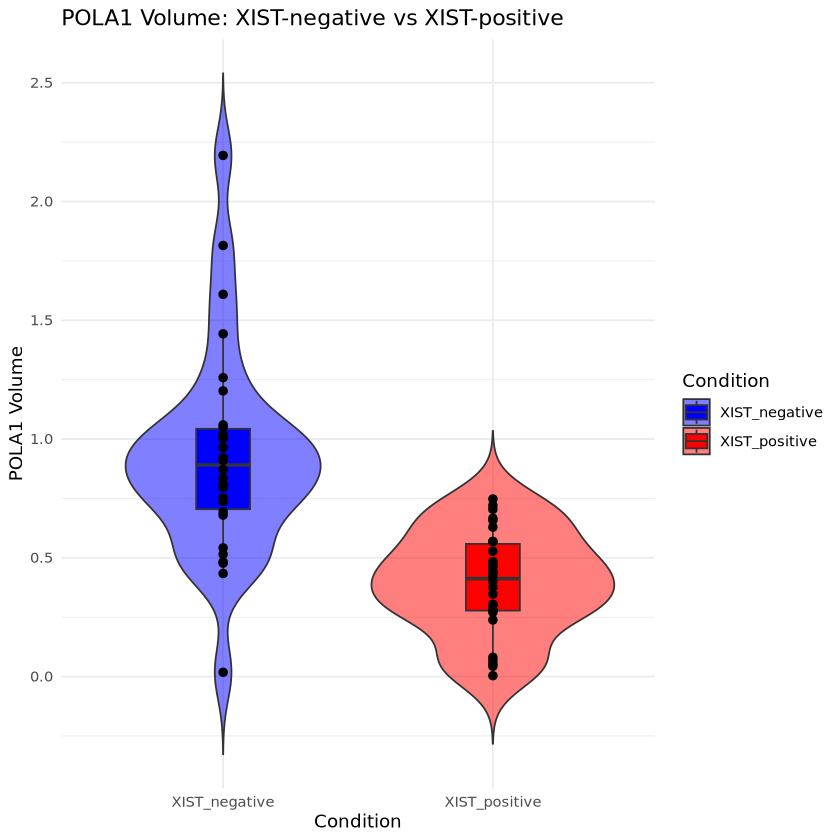

In [31]:
# Load the required libraries
library(ggplot2)
library(reshape2)

# Data (replace with your actual data)
XIST_negative <- c(1.6092811715847157, 0.7377378854006338, 1.019814135700876, 0.8064487668840261, 0.4773598082004101, 1.258494039801081, 1.4429285111512395, 0.9221723567507922, 0.6798760904672507, 0.0180818109166822, 0.4339634620003728, 0.8064487668840261, 1.0595941197175769, 0.8715432861840821, 0.5417601799930056, 0.7963874645897183, 0.7530466501902778, 1.2027075995844725, 0.96433312038755, 0.5146721709933554, 1.814896602976569, 0.9101571023882494, 2.194128728971673, 1.0022563329870604, 1.0076739347869905, 0.9209923059881095, 0.6934530303910472, 1.051014749186431, 0.8343106771892287, 0.482166560193775)

XIST_positive <- c(0.48459253256708296, 0.4014162023503448, 0.4701270838337372, 0.42311437545036346, 0.30377442340026095, 0.5279888787671202, 0.6581779173672321, 0.6292470199005405, 0.06871088148339236, 0.00361636218333644, 0.04339634620003728, 0.0542454327500466, 0.3761016670669898, 0.34717076960029825, 0.28171529359636294, 0.08126402699895084, 0.4604961529940548, 0.7476290483903478, 0.7042882339909073, 0.28171529359636294, 0.7205410393906975, 0.4388257457943346, 0.666365021391397, 0.2762976917964329, 0.5688481889926559, 0.5688481889926559, 0.4388257457943346, 0.2708800899965028, 0.3033857007960832, 0.23837447919692248)

# Create a data frame
df <- data.frame(
  XIST_negative = XIST_negative,
  XIST_positive = XIST_positive
)

# Reshape the data into long format
df_melt <- melt(df, variable.name = "Condition", value.name = "POLA1_Volume")

# Create the violin plot with the box plot overlay and individual data points
p3<- ggplot(df_melt, aes(x = Condition, y = POLA1_Volume, fill = Condition)) +
  geom_violin(trim = FALSE, alpha = 0.5) +   # Violin plot (trim = FALSE shows full distribution)
  geom_boxplot(width = 0.2, position = position_dodge(width = 0.9), outlier.shape = NA) +  # Overlay box plot
  geom_point(position = position_dodge(width = 0.9), shape = 21, color = "black", fill = "black", size = 2) +  # Add individual data points
  labs(title = "POLA1 Volume: XIST-negative vs XIST-positive", 
       x = "Condition", y = "POLA1 Volume") +
  theme_minimal() +
  scale_fill_manual(values = c("XIST_negative" = "blue", "XIST_positive" = "red"))
p3

In [32]:
output_path <- "/lustre1/project/stg_00041/Amitesh/FISH_quantification_random/"
filename <- "POLA1_volume quantification_naive.pdf"

In [33]:
ggsave(file.path(output_path, filename), plot = p3, height = 8, width = 8)

No id variables; using all as measure variables



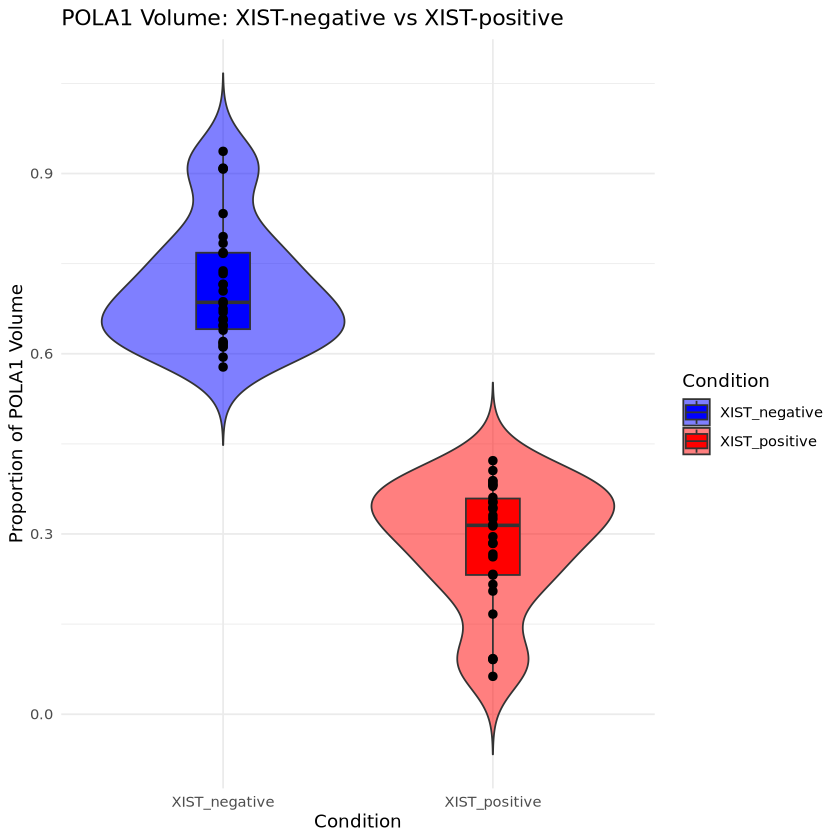

In [37]:
# Load the required libraries
library(ggplot2)
library(reshape2)

# Data (replace with your actual data)
XIST_negative <- c(0.768566494, 0.647619048, 0.684466019, 0.655882353, 0.611111111, 0.704453441, 0.686746988, 0.594405594, 0.90821256, 0.833333333, 0.909090909, 0.93697479, 0.738035264, 0.715133531, 0.657894737, 0.907407407, 0.620535714, 0.616666667, 0.577922078, 0.646258503, 0.715811966, 0.674698795, 0.767045455, 0.783898305, 0.639175258, 0.618181818, 0.612440191, 0.795081967, 0.733333333, 0.669172932)
XIST_positive <- c(0.231433506, 0.352380952, 0.315533981, 0.344117647, 0.388888889, 0.295546559, 0.313253012, 0.405594406, 0.09178744, 0.166666667, 0.090909091, 0.06302521, 0.261964736, 0.284866469, 0.342105263, 0.092592593, 0.379464286, 0.383333333, 0.422077922, 0.353741497, 0.284188034, 0.325301205, 0.232954545, 0.216101695, 0.360824742, 0.381818182, 0.387559809, 0.204918033, 0.266666667, 0.330827068)

# Create a data frame
df <- data.frame(
  XIST_negative = XIST_negative,
  XIST_positive = XIST_positive
)

# Reshape the data into long format
df_melt <- melt(df, variable.name = "Condition", value.name = "POLA1_Volume")

# Create the violin plot with the box plot overlay and individual data points
p1<- ggplot(df_melt, aes(x = Condition, y = POLA1_Volume, fill = Condition)) +
  geom_violin(trim = FALSE, alpha = 0.5) +   # Violin plot (trim = FALSE shows full distribution)
  geom_boxplot(width = 0.2, position = position_dodge(width = 0.9), outlier.shape = NA) +  # Overlay box plot
  geom_point(position = position_dodge(width = 0.9), shape = 21, color = "black", fill = "black", size = 2) +  # Add individual data points
  labs(title = "POLA1 Volume: XIST-negative vs XIST-positive", 
       x = "Condition", y = "Proportion of POLA1 Volume") +
  theme_minimal() +
  scale_fill_manual(values = c("XIST_negative" = "blue", "XIST_positive" = "red"))
p1

In [38]:
output_path <- "/lustre1/project/stg_00041/Amitesh/FISH_quantification_random/"
filename <- "proportion_of_POLA1_volume quantification_naive.pdf"

In [39]:
ggsave(file.path(output_path, filename), plot = p1, height = 8, width = 8)

No id variables; using all as measure variables



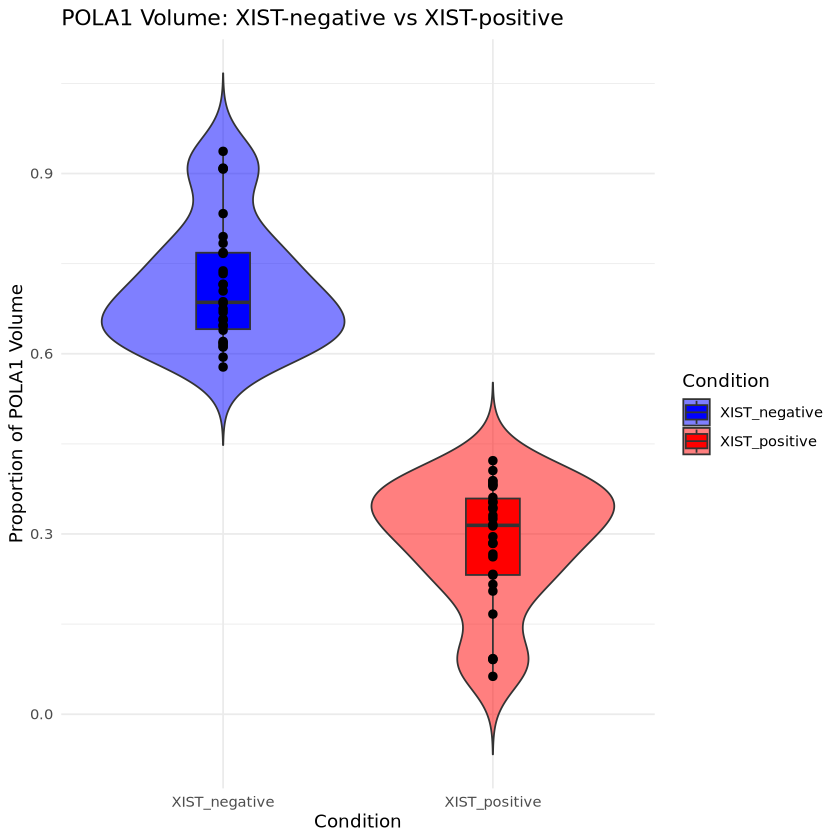

In [37]:
# Load the required libraries
library(ggplot2)
library(reshape2)

# Data (replace with your actual data)
XIST_negative <- c(0.768566494, 0.647619048, 0.684466019, 0.655882353, 0.611111111, 0.704453441, 0.686746988, 0.594405594, 0.90821256, 0.833333333, 0.909090909, 0.93697479, 0.738035264, 0.715133531, 0.657894737, 0.907407407, 0.620535714, 0.616666667, 0.577922078, 0.646258503, 0.715811966, 0.674698795, 0.767045455, 0.783898305, 0.639175258, 0.618181818, 0.612440191, 0.795081967, 0.733333333, 0.669172932)
XIST_positive <- c(0.231433506, 0.352380952, 0.315533981, 0.344117647, 0.388888889, 0.295546559, 0.313253012, 0.405594406, 0.09178744, 0.166666667, 0.090909091, 0.06302521, 0.261964736, 0.284866469, 0.342105263, 0.092592593, 0.379464286, 0.383333333, 0.422077922, 0.353741497, 0.284188034, 0.325301205, 0.232954545, 0.216101695, 0.360824742, 0.381818182, 0.387559809, 0.204918033, 0.266666667, 0.330827068)

# Create a data frame
df <- data.frame(
  XIST_negative = XIST_negative,
  XIST_positive = XIST_positive
)

# Reshape the data into long format
df_melt <- melt(df, variable.name = "Condition", value.name = "POLA1_Volume")

# Create the violin plot with the box plot overlay and individual data points
p1<- ggplot(df_melt, aes(x = Condition, y = POLA1_Volume, fill = Condition)) +
  geom_violin(trim = FALSE, alpha = 0.5) +   # Violin plot (trim = FALSE shows full distribution)
  geom_boxplot(width = 0.2, position = position_dodge(width = 0.9), outlier.shape = NA) +  # Overlay box plot
  geom_point(position = position_dodge(width = 0.9), shape = 21, color = "black", fill = "black", size = 2) +  # Add individual data points
  labs(title = "POLA1 Volume: XIST-negative vs XIST-positive", 
       x = "Condition", y = "Proportion of POLA1 Volume") +
  theme_minimal() +
  scale_fill_manual(values = c("XIST_negative" = "blue", "XIST_positive" = "red"))
p1

In [38]:
output_path <- "/lustre1/project/stg_00041/Amitesh/FISH_quantification_random/"
filename <- "proportion_of_POLA1_volume quantification_naive.pdf"

In [39]:
ggsave(file.path(output_path, filename), plot = p1, height = 8, width = 8)

## POLA1 max feret diameter pola1 naive final

No id variables; using all as measure variables



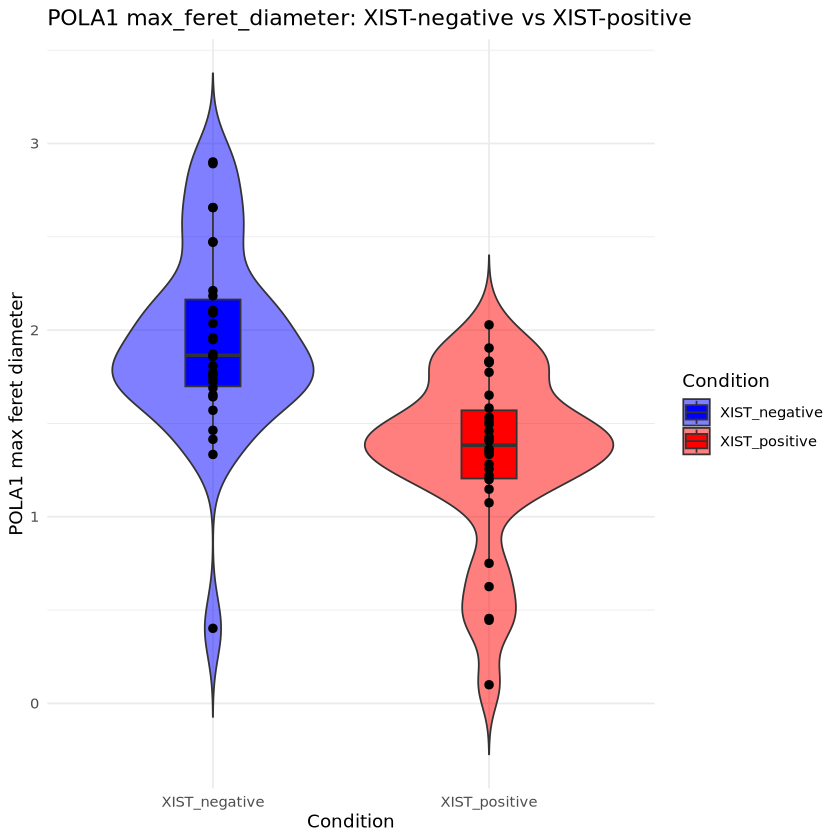

In [47]:
# Load the required libraries
library(ggplot2)
library(reshape2)

# Data (replace with your actual data)
XIST_negative <- c(2.656734645, 1.463255941, 2.211724817, 1.759499237, 1.736872669, 2.470629942, 2.891704604, 2.656734645, 1.948810124, 0.402375425, 1.642707154, 1.773734291, 2.035842452, 2.091913399, 1.415068495, 1.959837148, 1.808236784, 2.105565991, 2.095248751, 1.653370066, 2.901213663, 1.858108535, 2.473708781, 2.183585871, 1.872816405, 1.690363592, 1.57057444, 1.724571066, 1.762339585, 1.333868086)
XIST_positive <- c(1.360811881, 1.221402987, 1.534118431, 1.256430638, 1.147830731, 1.830794629, 1.834093083, 1.582531727, 0.625880713, 0.1, 0.455142272, 0.445518569, 1.360811881, 1.28129882, 1.412766132, 0.750620135, 1.774121929, 1.825945791, 1.904187645, 1.34884529, 2.02835221, 1.651455912, 1.426915446, 1.49639991, 1.460288084, 1.514378029, 1.406167354, 1.199578367, 1.333868086, 1.075031316)

# Create a data frame
df <- data.frame(
  XIST_negative = XIST_negative,
  XIST_positive = XIST_positive
)

# Reshape the data into long format
df_melt <- melt(df, variable.name = "Condition", value.name = "POLA1_maxferet_diameter")

# Create the violin plot with the box plot overlay and individual data points
p1<- ggplot(df_melt, aes(x = Condition, y = POLA1_maxferet_diameter, fill = Condition)) +
  geom_violin(trim = FALSE, alpha = 0.5) +   # Violin plot (trim = FALSE shows full distribution)
  geom_boxplot(width = 0.2, position = position_dodge(width = 0.9), outlier.shape = NA) +  # Overlay box plot
  geom_point(position = position_dodge(width = 0.9), shape = 21, color = "black", fill = "black", size = 2) +  # Add individual data points
  labs(title = "POLA1 max_feret_diameter: XIST-negative vs XIST-positive", 
       x = "Condition", y = "POLA1 max feret diameter") +
  theme_minimal() +
  scale_fill_manual(values = c("XIST_negative" = "blue", "XIST_positive" = "red"))
p1

In [48]:
output_path <- "/lustre1/project/stg_00041/Amitesh/FISH_quantification_random/"
filename <- "POLA1_max_feret_diameter_quantification_naive.pdf"

In [49]:
ggsave(file.path(output_path, filename), plot = p1, height = 8, width = 8)

No id variables; using all as measure variables



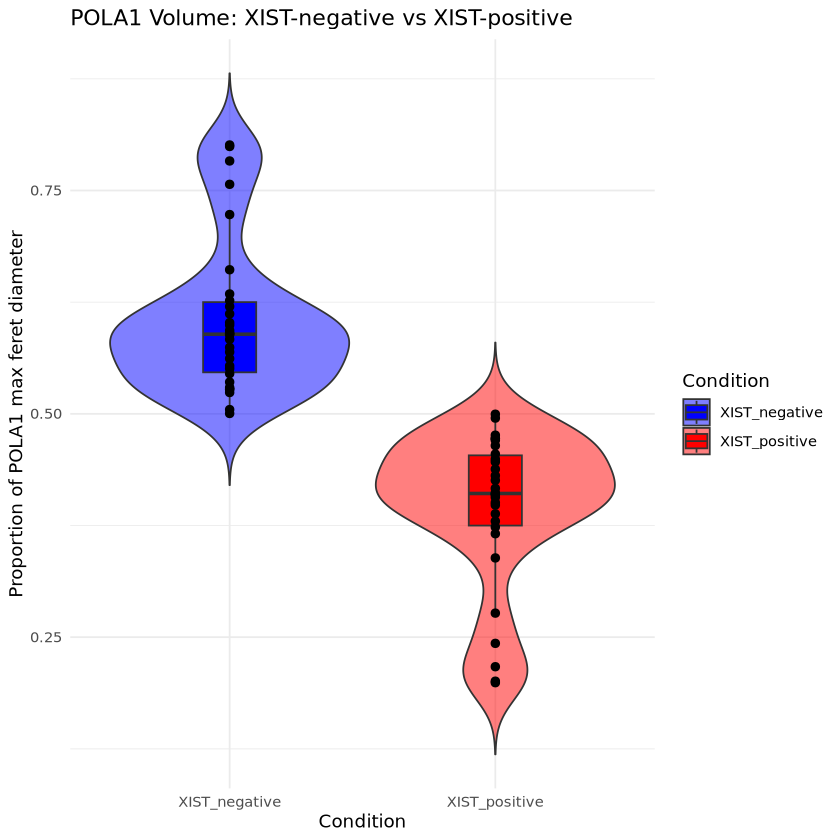

In [59]:
# Load the required libraries
library(ggplot2)
library(reshape2)

# Data (replace with your actual data)
XIST_negative <- c(0.661282857, 0.545043516, 0.590447777, 0.583401906, 0.602097487, 0.574374815, 0.611897672, 0.626696794, 0.756910343, 0.800945677, 0.783043403, 0.799248397, 0.599366981, 0.620154696, 0.500407089, 0.72306513, 0.504761507, 0.535561409, 0.523886004, 0.550716677, 0.588533298, 0.529441349, 0.634182797, 0.593368019, 0.561883497, 0.52745706, 0.527615275, 0.589768446, 0.569192952, 0.55372511)
XIST_positive <- c(0.338717143, 0.454956484, 0.409552223, 0.416598094, 0.397902513, 0.425625185, 0.388102328, 0.373303206, 0.243089657, 0.199054323, 0.216956597, 0.200751603, 0.400633019, 0.379845304, 0.499592911, 0.27693487, 0.495238493, 0.464438591, 0.476113996, 0.449283323, 0.411466702, 0.470558651, 0.365817203, 0.406631981, 0.438116503, 0.47254294, 0.472384725, 0.410231554, 0.430807048, 0.44627489)

# Create a data frame
df <- data.frame(
  XIST_negative = XIST_negative,
  XIST_positive = XIST_positive
)

# Reshape the data into long format
df_melt <- melt(df, variable.name = "Condition", value.name = "POLA1_maxferet_diameter")

# Create the violin plot with the box plot overlay and individual data points
p2<- ggplot(df_melt, aes(x = Condition, y = POLA1_maxferet_diameter, fill = Condition)) +
  geom_violin(trim = FALSE, alpha = 0.5) +   # Violin plot (trim = FALSE shows full distribution)
  geom_boxplot(width = 0.2, position = position_dodge(width = 0.9), outlier.shape = NA) +  # Overlay box plot
  geom_point(position = position_dodge(width = 0.9), shape = 21, color = "black", fill = "black", size = 2) +  # Add individual data points
  labs(title = "POLA1 Volume: XIST-negative vs XIST-positive", 
       x = "Condition", y = "Proportion of POLA1 max feret diameter") +
  theme_minimal() +
  scale_fill_manual(values = c("XIST_negative" = "blue", "XIST_positive" = "red"))
p2

In [60]:
output_path <- "/lustre1/project/stg_00041/Amitesh/FISH_quantification_random/"
filename <- "proportion_of_POLA1_max_feret_diameter_quantification_naive.pdf"

In [61]:
ggsave(file.path(output_path, filename), plot = p2, height = 8, width = 8)

In [63]:
output_path <- "/lustre1/project/stg_00041/Amitesh/FISH_quantification_random/"
filename <- "Proportion_of_POLA1_max_feret_diameter_quantification_naive_bar_plot.pdf"

In [64]:
ggsave(file.path(output_path, filename), plot = p6, height = 8, width = 8)

## Plotting bar plot for qPCR data for fig s5d and e

# XIST

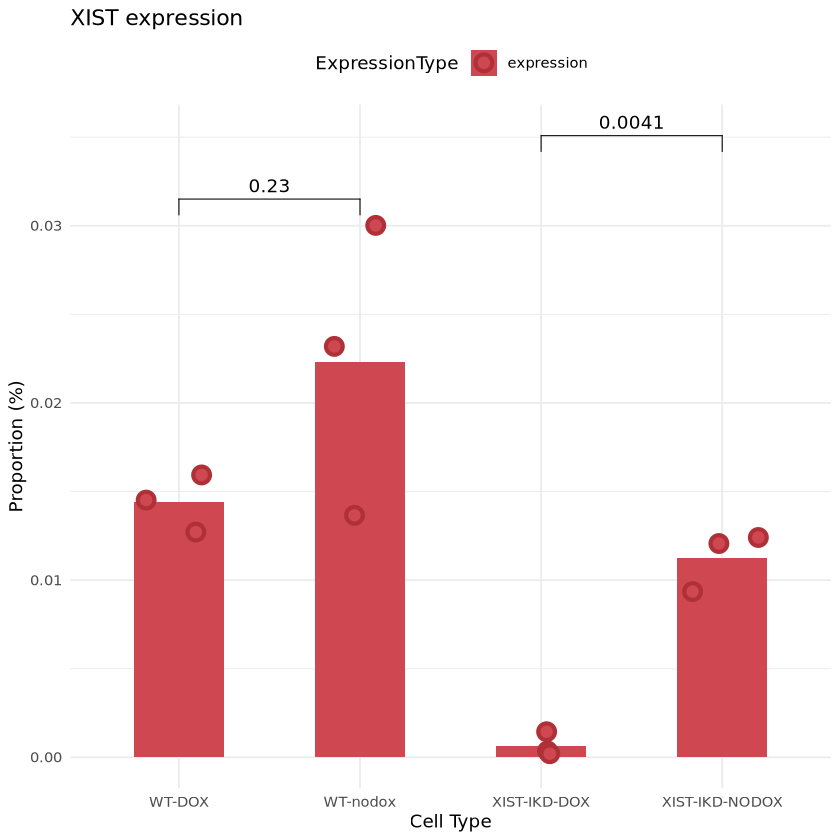

In [115]:
# Load necessary libraries
library(tidyverse)
library(ggpubr)

# Your original data
data_XIST_qPCR <- data.frame(
  Experiment = rep(c('EXP1', 'EXP2', 'EXP3'), each = 4),
  Cell_type = rep(c('WT-nodox', 'WT-DOX', 'XIST-IKD-NODOX', 'XIST-IKD-DOX'), times = 3),
  expression = c(0.030014314, 0.012718136, 0.012383474, 0.000382648, 0.013696084, 0.01595841, 0.012135414, 0.001382585, 0.023215975, 0.014499767, 0.009308463, 0.000202273)
)

# Long format (though not strictly needed here, kept for completeness)
data_long_XIST <- data_XIST_qPCR %>%
  pivot_longer(cols = c("expression"), names_to = "ExpressionType", values_to = "Proportion")

# Define comparisons
my_comparisons <- list(
  c("WT-nodox", "WT-DOX"),
  c("XIST-IKD-NODOX", "XIST-IKD-DOX")
)

# Plot
p_XIST <- ggplot(data_long_XIST, aes(x = Cell_type, y = Proportion, fill = ExpressionType)) +
  geom_bar(stat = "summary", fun = "mean", position = "stack", width = 0.5) +
  geom_point(aes(color = ExpressionType), position = position_jitter(width = 0.2), 
             size = 3.5, shape = 21, stroke = 1.8) +
  stat_compare_means(comparisons = my_comparisons, method = "t.test", label = "p.format") +
  labs(title = "XIST expression",
       x = "Cell Type",
       y = "Proportion (%)") +
  scale_fill_manual(values = c("expression" = "#ce4751")) +
  scale_color_manual(values = c("expression" = "#b03038")) +
  theme_minimal() +
  theme(legend.position = "top")

# Display plot
p_XIST

In [116]:
output_path <- "/lustre1/project/stg_00041/Amitesh/FISH_quantification_random/"
filename <- "XIST_qPCR.pdf"

In [117]:
ggsave(file.path(output_path, filename), plot = p_XIST, height = 8, width = 8)

# NANOG

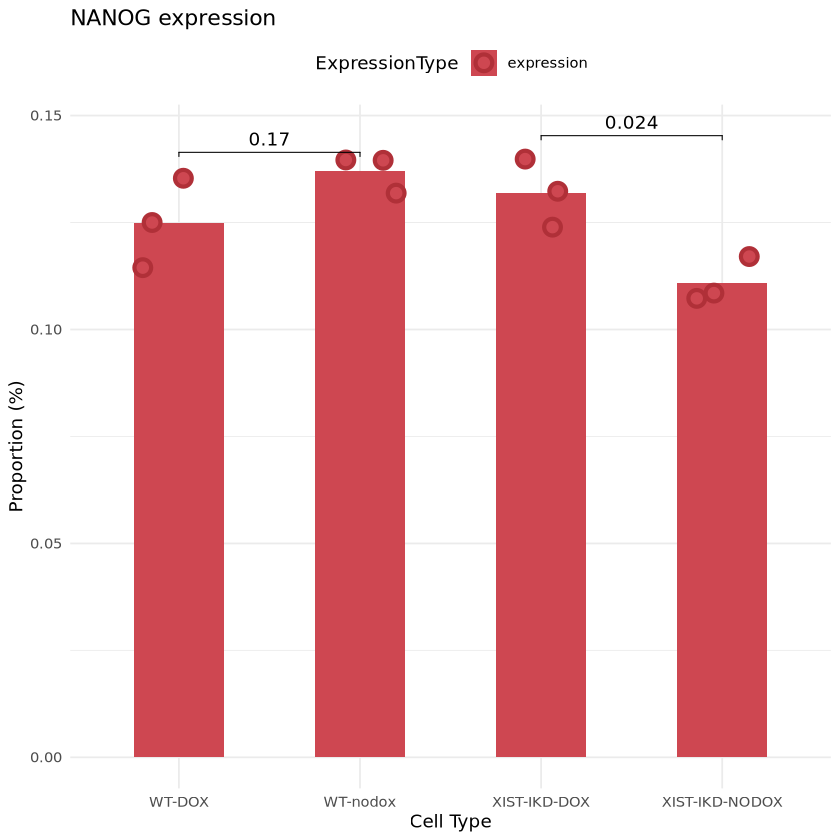

In [107]:
# Load necessary libraries
library(tidyverse)
library(ggpubr)

# Your original data
data_NANOG_qPCR <- data.frame(
  Experiment = rep(c('EXP1', 'EXP2', 'EXP3'), each = 4),
  Cell_type = rep(c('WT-nodox', 'WT-DOX', 'XIST-IKD-NODOX', 'XIST-IKD-DOX'), times = 3),
  expression = c(0.139499598, 0.124999627, 0.108453415, 0.123874351, 0.131822081, 0.135387757, 0.107319926, 0.132274791, 0.139642099, 0.11445616, 0.117093842, 0.139779703)
)

# Long format (though not strictly needed here, kept for completeness)
data_long_NANOG <- data_NANOG_qPCR %>%
  pivot_longer(cols = c("expression"), names_to = "ExpressionType", values_to = "Proportion")

# Define comparisons
my_comparisons <- list(
  c("WT-nodox", "WT-DOX"),
  c("XIST-IKD-NODOX", "XIST-IKD-DOX")
)

# Plot
p_NANOG <- ggplot(data_long_NANOG, aes(x = Cell_type, y = Proportion, fill = ExpressionType)) +
  geom_bar(stat = "summary", fun = "mean", position = "stack", width = 0.5) +
  geom_point(aes(color = ExpressionType), position = position_jitter(width = 0.2), 
             size = 3.5, shape = 21, stroke = 1.8) +
  stat_compare_means(comparisons = my_comparisons, method = "t.test", label = "p.format") +
  labs(title = "NANOG expression",
       x = "Cell Type",
       y = "Proportion (%)") +
  scale_fill_manual(values = c("expression" = "#ce4751")) +
  scale_color_manual(values = c("expression" = "#b03038")) +
  theme_minimal() +
  theme(legend.position = "top")

# Display plot
p_NANOG

In [108]:
output_path <- "/lustre1/project/stg_00041/Amitesh/FISH_quantification_random/"
filename <- "NANOG_qPCR.pdf"

In [109]:
ggsave(file.path(output_path, filename), plot = p_NANOG, height = 8, width = 8)

# OCT4

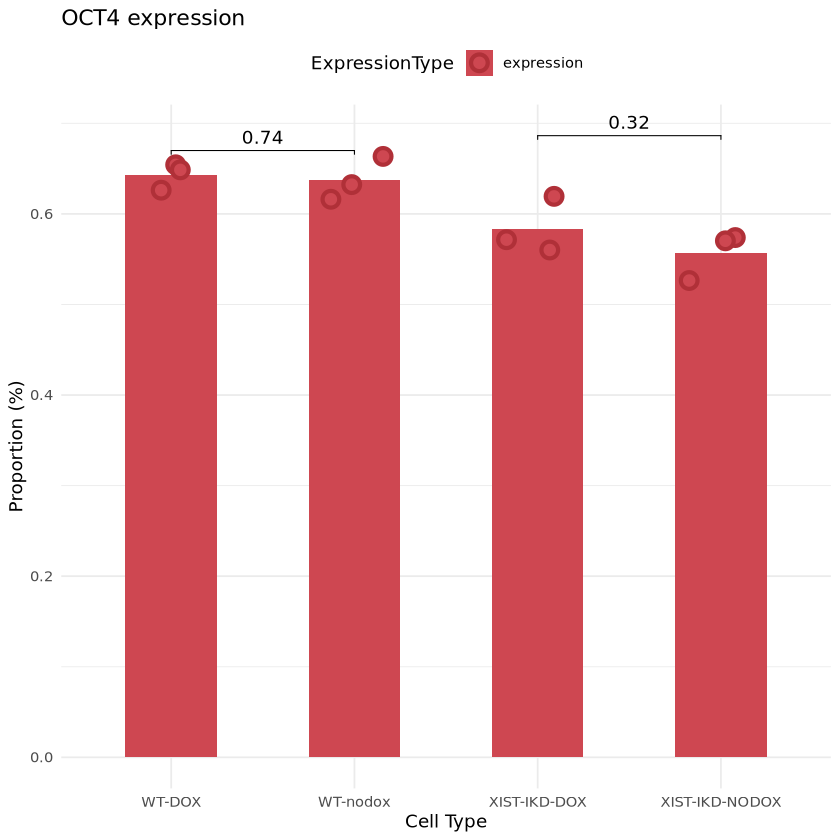

In [104]:
# Load necessary libraries
library(tidyverse)
library(ggpubr)

# Your original data
data_OCT4_qPCR <- data.frame(
  Experiment = rep(c('EXP1', 'EXP2', 'EXP3'), each = 4),
  Cell_type = rep(c('WT-nodox', 'WT-DOX', 'XIST-IKD-NODOX', 'XIST-IKD-DOX'), times = 3),
  expression = c(0.61624113, 0.654564598, 0.573677141, 0.559986025, 0.63218087, 0.64889699, 0.52619785, 0.57157933, 0.663074905, 0.625763963, 0.570474509, 0.619766427)
)

# Long format (though not strictly needed here, kept for completeness)
data_long_OCT4 <- data_OCT4_qPCR %>%
  pivot_longer(cols = c("expression"), names_to = "ExpressionType", values_to = "Proportion")

# Define comparisons
my_comparisons <- list(
  c("WT-nodox", "WT-DOX"),
  c("XIST-IKD-NODOX", "XIST-IKD-DOX")
)

# Plot
p_OCT4 <- ggplot(data_long_OCT4, aes(x = Cell_type, y = Proportion, fill = ExpressionType)) +
  geom_bar(stat = "summary", fun = "mean", position = "stack", width = 0.5) +
  geom_point(aes(color = ExpressionType), position = position_jitter(width = 0.2), 
             size = 3.5, shape = 21, stroke = 1.8) +
  stat_compare_means(comparisons = my_comparisons, method = "t.test", label = "p.format") +
  labs(title = "OCT4 expression",
       x = "Cell Type",
       y = "Proportion (%)") +
  scale_fill_manual(values = c("expression" = "#ce4751")) +
  scale_color_manual(values = c("expression" = "#b03038")) +
  theme_minimal() +
  theme(legend.position = "top")

# Display plot
p_OCT4

In [105]:
output_path <- "/lustre1/project/stg_00041/Amitesh/FISH_quantification_random/"
filename <- "OCT4_qPCR.pdf"

In [106]:
ggsave(file.path(output_path, filename), plot = p_OCT4, height = 8, width = 8)

# KLF4

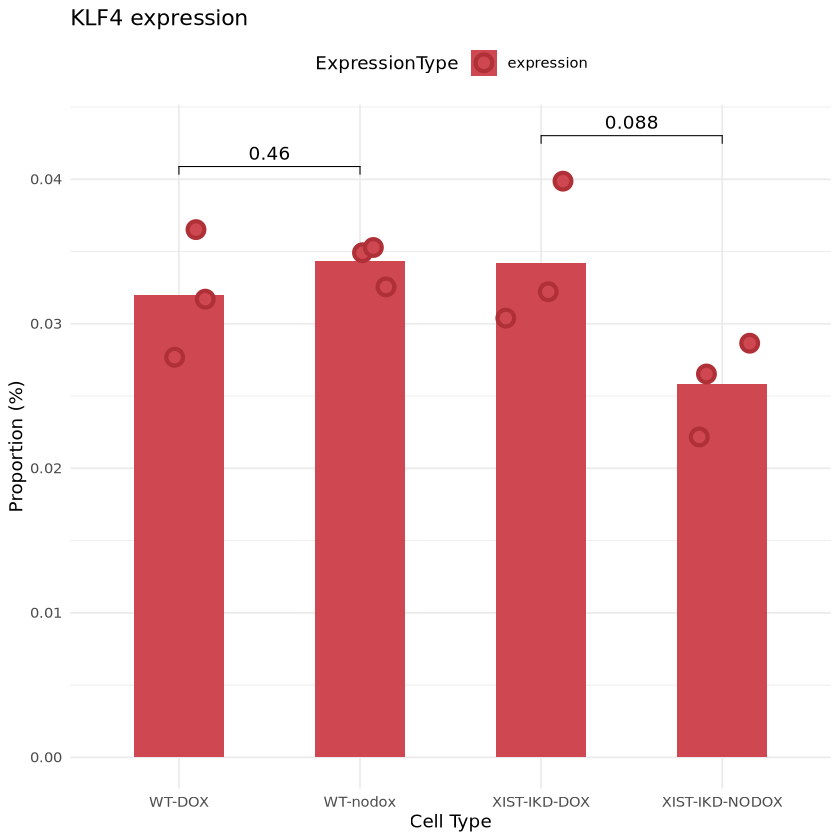

In [101]:
# Load necessary libraries
library(tidyverse)
library(ggpubr)

# Your original data
data_KLF4_qPCR <- data.frame(
  Experiment = rep(c('EXP1', 'EXP2', 'EXP3'), each = 4),
  Cell_type = rep(c('WT-nodox', 'WT-DOX', 'XIST-IKD-NODOX', 'XIST-IKD-DOX'), times = 3),
  expression = c(0.03499367, 0.03161026, 0.022204256, 0.039993015, 0.032579541, 0.036579794, 0.026674901, 0.032199797, 0.035408137, 0.027786742, 0.028632478, 0.030339067)
)

# Long format (though not strictly needed here, kept for completeness)
data_long_KLF4 <- data_KLF4_qPCR %>%
  pivot_longer(cols = c("expression"), names_to = "ExpressionType", values_to = "Proportion")

# Define comparisons
my_comparisons <- list(
  c("WT-nodox", "WT-DOX"),
  c("XIST-IKD-NODOX", "XIST-IKD-DOX")
)

# Plot
p_KLF4 <- ggplot(data_long_KLF4, aes(x = Cell_type, y = Proportion, fill = ExpressionType)) +
  geom_bar(stat = "summary", fun = "mean", position = "stack", width = 0.5) +
  geom_point(aes(color = ExpressionType), position = position_jitter(width = 0.2), 
             size = 3.5, shape = 21, stroke = 1.8) +
  stat_compare_means(comparisons = my_comparisons, method = "t.test", label = "p.format") +
  labs(title = "KLF4 expression",
       x = "Cell Type",
       y = "Proportion (%)") +
  scale_fill_manual(values = c("expression" = "#ce4751")) +
  scale_color_manual(values = c("expression" = "#b03038")) +
  theme_minimal() +
  theme(legend.position = "top")

# Display plot
p_KLF4

In [102]:
output_path <- "/lustre1/project/stg_00041/Amitesh/FISH_quantification_random/"
filename <- "KLF4_qPCR.pdf"

In [103]:
ggsave(file.path(output_path, filename), plot = p_KLF4, height = 8, width = 8)

# LBP9

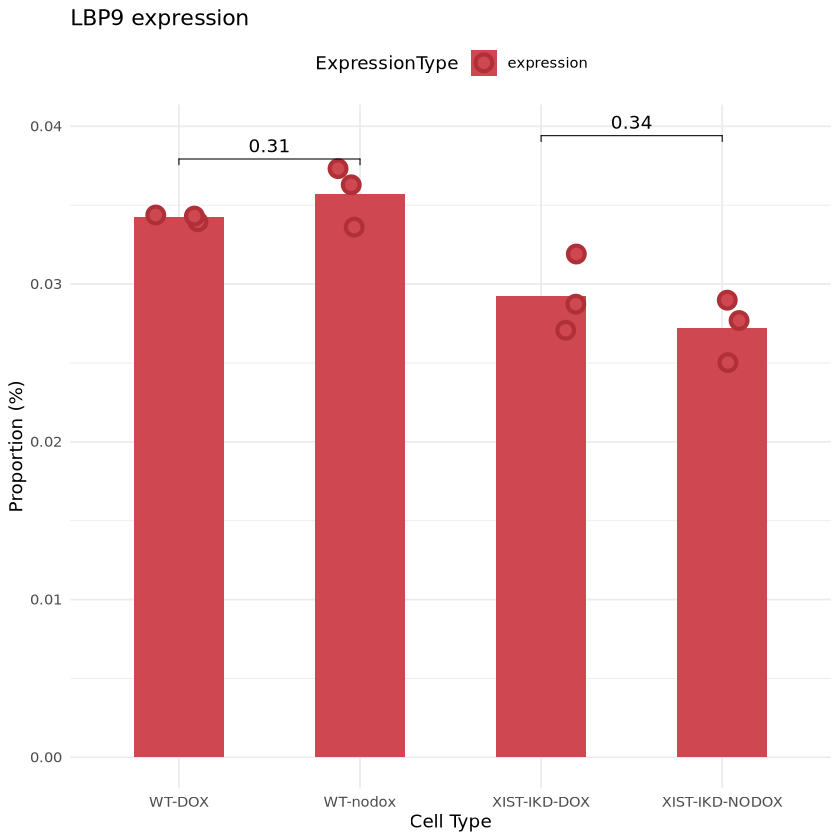

In [98]:
# Load necessary libraries
library(tidyverse)
library(ggpubr)

# Your original data
data_LBP9_qPCR <- data.frame(
  Experiment = rep(c('EXP1', 'EXP2', 'EXP3'), each = 4),
  Cell_type = rep(c('WT-nodox', 'WT-DOX', 'XIST-IKD-NODOX', 'XIST-IKD-DOX'), times = 3),
  expression = c(0.037313403, 0.033966206, 0.02501069, 0.027077715,
                 0.033582705, 0.034315127, 0.02766662, 0.031890714,
                 0.036288658, 0.03439112, 0.028966591, 0.028703949)
)

# Long format (though not strictly needed here, kept for completeness)
data_long_LBP9 <- data_LBP9_qPCR %>%
  pivot_longer(cols = c("expression"), names_to = "ExpressionType", values_to = "Proportion")

# Define comparisons
my_comparisons <- list(
  c("WT-nodox", "WT-DOX"),
  c("XIST-IKD-NODOX", "XIST-IKD-DOX")
)

# Plot
p_LBP9 <- ggplot(data_long_LBP9, aes(x = Cell_type, y = Proportion, fill = ExpressionType)) +
  geom_bar(stat = "summary", fun = "mean", position = "stack", width = 0.5) +
  geom_point(aes(color = ExpressionType), position = position_jitter(width = 0.2), 
             size = 3.5, shape = 21, stroke = 1.8) +
  stat_compare_means(comparisons = my_comparisons, method = "t.test", label = "p.format") +
  labs(title = "LBP9 expression",
       x = "Cell Type",
       y = "Proportion (%)") +
  scale_fill_manual(values = c("expression" = "#ce4751")) +
  scale_color_manual(values = c("expression" = "#b03038")) +
  theme_minimal() +
  theme(legend.position = "top")

# Display plot
p_LBP9

In [99]:
output_path <- "/lustre1/project/stg_00041/Amitesh/FISH_quantification_random/"
filename <- "LBP9_qPCR.pdf"

In [100]:
ggsave(file.path(output_path, filename), plot = p_LBP9, height = 8, width = 8)

## I want to make a box plot to compare the gray intensity value of DAPI user XIST foci accross all conditions

In [12]:
data_path <- "/lustre1/project/stg_00041/Amitesh/DAPI_COMPACTION/"

all_data <- list.files(path = data_path, pattern = "\\.txt$", recursive = TRUE, full.names = TRUE) %>%
  set_names() %>%
  map_dfr(~ read_table(.x, col_names = c("Distance", "DAPI", "XIST")) %>%
            mutate(
              Nucleus = tools::file_path_sans_ext(basename(.x)),
              Condition = basename(dirname(.x))  # gets the folder name
            ),
          .id = "File")


── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
cols(
  Distance = col_character(),
  DAPI = col_character(),
  XIST = col_character()
)


── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
cols(
  Distance = col_character(),
  DAPI = col_character(),
  XIST = col_character()
)


── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
cols(
  Distance = col_character(),
  DAPI = col_character(),
  XIST = col_character()
)


── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
cols(
  Distance = col_character(),
  DAPI = col_character(),
  XIST = col_character()
)



In [13]:
all_data

File,Distance,DAPI,XIST,Nucleus,Condition
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
/lustre1/project/stg_00041/Amitesh/DAPI_COMPACTION//exmc/1.txt,Distance_(microns),DAPI,XIST,1,exmc
/lustre1/project/stg_00041/Amitesh/DAPI_COMPACTION//exmc/1.txt,0,1687,609,1,exmc
/lustre1/project/stg_00041/Amitesh/DAPI_COMPACTION//exmc/1.txt,0.2082,1340.057,684.887,1,exmc
/lustre1/project/stg_00041/Amitesh/DAPI_COMPACTION//exmc/1.txt,0.4164,1457.113,670.906,1,exmc
/lustre1/project/stg_00041/Amitesh/DAPI_COMPACTION//exmc/1.txt,0.6246,1246.34,509.283,1,exmc
/lustre1/project/stg_00041/Amitesh/DAPI_COMPACTION//exmc/1.txt,0.8327,1166.981,493.755,1,exmc
/lustre1/project/stg_00041/Amitesh/DAPI_COMPACTION//exmc/1.txt,1.0409,1040.057,522.868,1,exmc
/lustre1/project/stg_00041/Amitesh/DAPI_COMPACTION//exmc/1.txt,1.2491,967,526.981,1,exmc
/lustre1/project/stg_00041/Amitesh/DAPI_COMPACTION//exmc/1.txt,1.4573,822.132,602.132,1,exmc


In [14]:
df_clean <- all_data %>% filter(Distance != "Distance_(microns)")


In [15]:
df_clean

File,Distance,DAPI,XIST,Nucleus,Condition
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
/lustre1/project/stg_00041/Amitesh/DAPI_COMPACTION//exmc/1.txt,0,1687,609,1,exmc
/lustre1/project/stg_00041/Amitesh/DAPI_COMPACTION//exmc/1.txt,0.2082,1340.057,684.887,1,exmc
/lustre1/project/stg_00041/Amitesh/DAPI_COMPACTION//exmc/1.txt,0.4164,1457.113,670.906,1,exmc
/lustre1/project/stg_00041/Amitesh/DAPI_COMPACTION//exmc/1.txt,0.6246,1246.34,509.283,1,exmc
/lustre1/project/stg_00041/Amitesh/DAPI_COMPACTION//exmc/1.txt,0.8327,1166.981,493.755,1,exmc
/lustre1/project/stg_00041/Amitesh/DAPI_COMPACTION//exmc/1.txt,1.0409,1040.057,522.868,1,exmc
/lustre1/project/stg_00041/Amitesh/DAPI_COMPACTION//exmc/1.txt,1.2491,967,526.981,1,exmc
/lustre1/project/stg_00041/Amitesh/DAPI_COMPACTION//exmc/1.txt,1.4573,822.132,602.132,1,exmc
/lustre1/project/stg_00041/Amitesh/DAPI_COMPACTION//exmc/1.txt,1.6655,884.906,552.491,1,exmc


In [16]:
df_clean <- df_clean %>%
  mutate(
    Distance = as.numeric(Distance),
    DAPI = as.numeric(DAPI),
    XIST = as.numeric(XIST)
  )

In [48]:
# Define the XIST cloud as top N% of XIST intensity within each nucleus
library(dplyr)

df_cloud <- df_clean %>%
  group_by(Nucleus) %>%
  mutate(
    XIST_threshold = quantile(XIST, 0.92, na.rm = TRUE),  # top 10% as cloud
    in_cloud = XIST >= XIST_threshold
  )

In [49]:
df_cloud

File,Distance,DAPI,XIST,Nucleus,Condition,XIST_threshold,in_cloud
<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<lgl>
/lustre1/project/stg_00041/Amitesh/DAPI_COMPACTION//exmc/1.txt,0.0000,1687.000,609.000,1,exmc,1641.158,FALSE
/lustre1/project/stg_00041/Amitesh/DAPI_COMPACTION//exmc/1.txt,0.2082,1340.057,684.887,1,exmc,1641.158,FALSE
/lustre1/project/stg_00041/Amitesh/DAPI_COMPACTION//exmc/1.txt,0.4164,1457.113,670.906,1,exmc,1641.158,FALSE
/lustre1/project/stg_00041/Amitesh/DAPI_COMPACTION//exmc/1.txt,0.6246,1246.340,509.283,1,exmc,1641.158,FALSE
/lustre1/project/stg_00041/Amitesh/DAPI_COMPACTION//exmc/1.txt,0.8327,1166.981,493.755,1,exmc,1641.158,FALSE
/lustre1/project/stg_00041/Amitesh/DAPI_COMPACTION//exmc/1.txt,1.0409,1040.057,522.868,1,exmc,1641.158,FALSE
/lustre1/project/stg_00041/Amitesh/DAPI_COMPACTION//exmc/1.txt,1.2491,967.000,526.981,1,exmc,1641.158,FALSE
/lustre1/project/stg_00041/Amitesh/DAPI_COMPACTION//exmc/1.txt,1.4573,822.132,602.132,1,exmc,1641.158,FALSE
/lustre1/project/stg_00041/Amitesh/DAPI_COMPACTION//exmc/1.txt,1.6655,884.906,552.491,1,exmc,1641.158,FALSE


In [50]:
df_dapi_summary <- df_cloud %>%
  group_by(Nucleus, Condition, in_cloud) %>%
  summarise(mean_DAPI = mean(DAPI, na.rm = TRUE), .groups = "drop")

In [52]:
library(tidyr)
df_wide <- df_dapi_summary %>%
  pivot_wider(names_from = in_cloud, values_from = mean_DAPI, 
              names_prefix = "DAPI_")


In [53]:
df_wide <- df_wide %>%
  mutate(DAPI_ratio = DAPI_TRUE / DAPI_FALSE)


Warning message:
“Removed 6 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 6 rows containing non-finite outside the scale range (`stat_signif()`).”


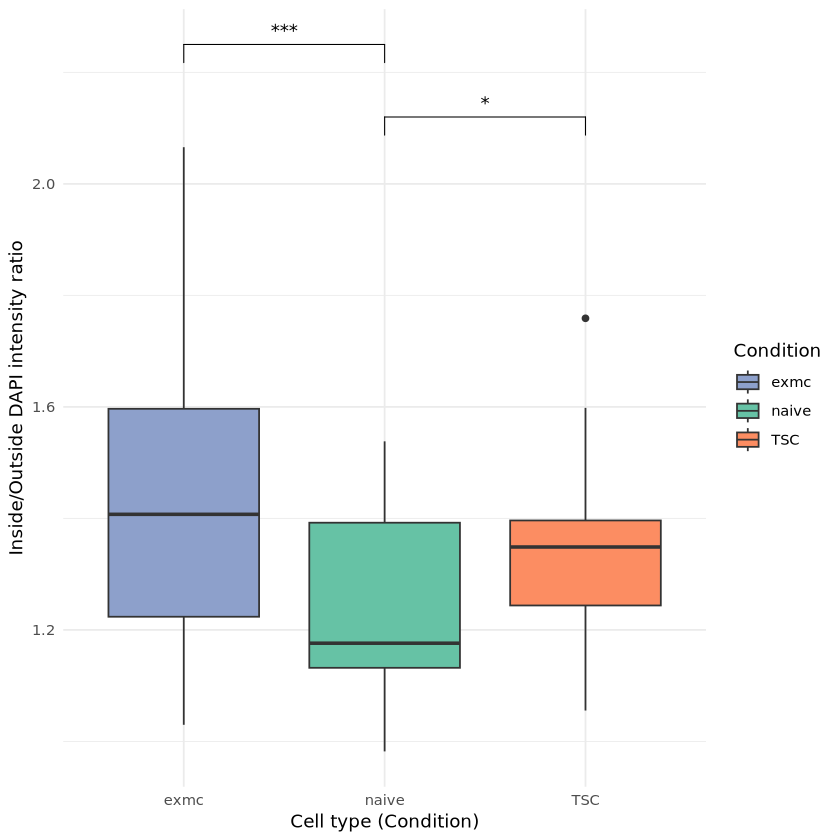

In [54]:
library(ggplot2)
library(ggpubr)

ggplot(df_wide, aes(x = Condition, y = DAPI_ratio, fill = Condition)) +
  geom_boxplot() +
  scale_fill_manual(values = c("naive" = "#66c2a5", 
                               "TSC" = "#fc8d62", 
                               "exmc" = "#8da0cb")) +
  stat_compare_means(comparisons = list(c("naive", "TSC"), 
                                        c("naive", "exmc")),
                     method = "wilcox.test", 
                     label = "p.signif") +
  labs(y = "Inside/Outside DAPI intensity ratio",
       x = "Cell type (Condition)") +
  theme_minimal()


## Plotting DAPI and H3K27me3 quantification

## H3K27me3 signal quantification outside the Xi in naive TSC and EXMC

In [55]:
# Load the required libraries
library(ggplot2)
library(reshape2)

# Data (replace with your actual data)
Naive <- c(364.301,236.478,203.975,269.958,249.514,326.386,260.101,210.923,204.364,220.714,221.624,386.758,232.999,174.716,191.737,224.979,211.239,274.56,289.064,221.542,301.187,382.953,233.862,201.7,233.896,495.489,455.798,441.741,354.3,215.957)
EXMC <- c(434.082,365.727,504.937,377.553,297.825,414.184,494.516,585.145,610.914,122.785,290.575,395.014,375.383,291.352,375.872,568.923,314.993,306.076,446.523,407.905,775.817,311.366,418.32,406.051,307.11,300.916,458.304,495.497,477.594,397.441)
TSC <- c(714.122,619.363,583.782,617.915,574.45,464.666,554.5,736.261,850.423,1033.823,839.665,674.791,675.285,542.392,635.396,683.933,475.829,371.677,626.702,775.681,646.082,504.641,599.586,526.511,311.089,291.384,201.405,382.347,304.988,399.949)
max_length <- max(length(Naive), length(EXMC), length(TSC))

Naive <- c(Naive, rep(NA, max_length - length(Naive)))
EXMC <- c(EXMC, rep(NA, max_length - length(EXMC)))
TSC <- c(TSC, rep(NA, max_length - length(TSC)))

# Create a data frame
df_1 <- data.frame(
  Naive = Naive,
  EXMC = EXMC,
    TSC = TSC
)


Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths




In [56]:
df_1

Naive,EXMC,TSC
<dbl>,<dbl>,<dbl>
364.301,434.082,714.122
236.478,365.727,619.363
203.975,504.937,583.782
269.958,377.553,617.915
249.514,297.825,574.450
326.386,414.184,464.666
260.101,494.516,554.500
210.923,585.145,736.261
204.364,610.914,850.423


In [57]:
df_melt_1 <- melt(df_1, variable.name = "Condition", value.name = "H3K27ME3_gray_intensity_value")

No id variables; using all as measure variables



In [58]:
df_melt_1


Condition,H3K27ME3_gray_intensity_value
<fct>,<dbl>
Naive,364.301
Naive,236.478
Naive,203.975
Naive,269.958
Naive,249.514
Naive,326.386
Naive,260.101
Naive,210.923
Naive,204.364


## Combining stats on the plots

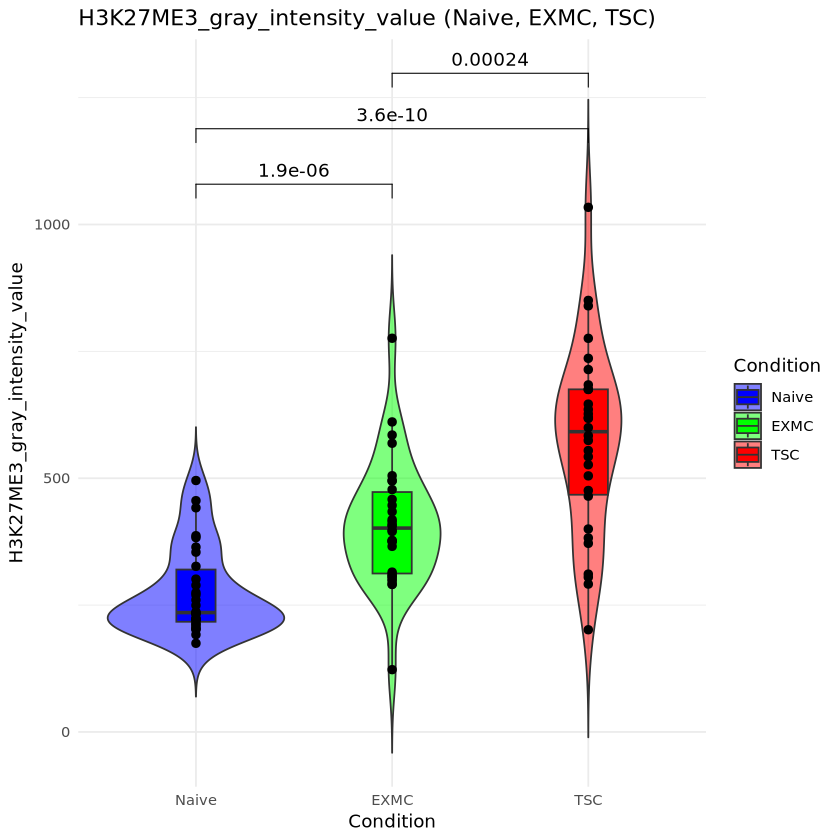

In [60]:
library(ggpubr)

# Define comparisons
my_comparisons <- list(c("Naive", "EXMC"), c("Naive", "TSC"), c("EXMC", "TSC"))

# Create plot
p3 <- ggplot(df_melt_1, aes(x = Condition, y = H3K27ME3_gray_intensity_value, fill = Condition)) +
  geom_violin(trim = FALSE, alpha = 0.5) +
  geom_boxplot(width = 0.2, position = position_dodge(width = 0.9), outlier.shape = NA) +
  geom_point(position = position_dodge(width = 0.9), shape = 21, color = "black", fill = "black", size = 2) +
  labs(title = "H3K27ME3_gray_intensity_value (Naive, EXMC, TSC)", 
       x = "Condition", y = "H3K27ME3_gray_intensity_value") +
  theme_minimal() +
  scale_fill_manual(values = c("Naive" = "blue", "EXMC" = "green", "TSC" = "red")) +
  stat_compare_means(comparisons = my_comparisons, method = "wilcox.test", label = "p.format")
p3

In [62]:
output_path <- "/lustre1/project/stg_00041/Amitesh/H3K27me3_gray_value_quantificaion/"
filename <- "H3K27ME3_gray_intensity_value_naive_EXMC_TSC.pdf"

In [63]:
ggsave(file.path(output_path, filename), plot = p3, height = 8, width = 8)

## H3K27me3 signal quantification inside the Xi in naive TSC and EXMC

In [64]:
# Load the required libraries
library(ggplot2)
library(reshape2)

# Data (replace with your actual data)
Naive <- c(705.72,551.344,454.948,449.968,381.734,821.647,678.31,668.529,529.853,558.285,874.441,768.813,514.835,555.5,481.341,616.167,384.022,517.63,511.282,617.648,657.491,659,460.508,378.966,524.252,785.605,943.75,941.741,848.875,663.819)
EXMC <- c(1416.2,1146.569,1209.77,1311.933,927.148,1150.396,1375.516,1530.055,1512.861,991.686,877.618,787.31,1082.238,704.771,1164.226,937.978,713.927,720.841,1230.264,1190.25,1605.018,704.704,1092.957,943.464,1117.345,683.165,971.214,1387.361,1079.163,1128.094)
TSC <- c(1402.512,1183.578,1664.908,1183.092,1754.532,1227.295,1486.684,1410.459,1580.27,1634.736,1785.114,1243.853,1077.824,1152,1142.384,1428.145,974.568,1057.507,1365.966,1554.172,1510.718,1299.842,1341.282,1365.183,818.605,709.89,874.74,698.524,664.112,707.025)
max_length <- max(length(Naive), length(EXMC), length(TSC))

Naive <- c(Naive, rep(NA, max_length - length(Naive)))
EXMC <- c(EXMC, rep(NA, max_length - length(EXMC)))
TSC <- c(TSC, rep(NA, max_length - length(TSC)))

# Create a data frame
df_2 <- data.frame(
  Naive = Naive,
  EXMC = EXMC,
    TSC = TSC
)

In [65]:
df_2

Naive,EXMC,TSC
<dbl>,<dbl>,<dbl>
705.720,1416.200,1402.512
551.344,1146.569,1183.578
454.948,1209.770,1664.908
449.968,1311.933,1183.092
381.734,927.148,1754.532
821.647,1150.396,1227.295
678.310,1375.516,1486.684
668.529,1530.055,1410.459
529.853,1512.861,1580.270


In [66]:
df_melt_2 <- melt(df_2, variable.name = "Condition", value.name = "H3K27ME3_gray_intensity_value_inside_Xi")

No id variables; using all as measure variables



In [67]:
df_melt_2


Condition,H3K27ME3_gray_intensity_value_inside_Xi
<fct>,<dbl>
Naive,705.720
Naive,551.344
Naive,454.948
Naive,449.968
Naive,381.734
Naive,821.647
Naive,678.310
Naive,668.529
Naive,529.853


## Combining stats on the plots

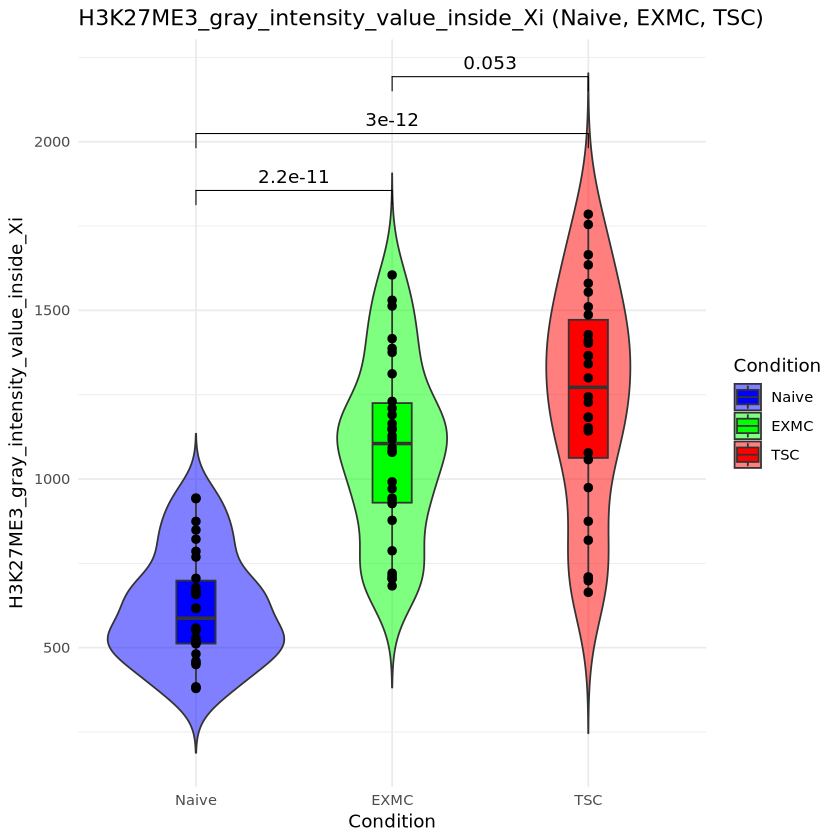

In [68]:
library(ggpubr)

# Define comparisons
my_comparisons <- list(c("Naive", "EXMC"), c("Naive", "TSC"), c("EXMC", "TSC"))

# Create plot
p4 <- ggplot(df_melt_2, aes(x = Condition, y = H3K27ME3_gray_intensity_value_inside_Xi, fill = Condition)) +
  geom_violin(trim = FALSE, alpha = 0.5) +
  geom_boxplot(width = 0.2, position = position_dodge(width = 0.9), outlier.shape = NA) +
  geom_point(position = position_dodge(width = 0.9), shape = 21, color = "black", fill = "black", size = 2) +
  labs(title = "H3K27ME3_gray_intensity_value_inside_Xi (Naive, EXMC, TSC)", 
       x = "Condition", y = "H3K27ME3_gray_intensity_value_inside_Xi") +
  theme_minimal() +
  scale_fill_manual(values = c("Naive" = "blue", "EXMC" = "green", "TSC" = "red")) +
  stat_compare_means(comparisons = my_comparisons, method = "wilcox.test", label = "p.format")
p4

In [69]:
output_path <- "/lustre1/project/stg_00041/Amitesh/H3K27me3_gray_value_quantificaion/"
filename <- "H3K27ME3_gray_intensity_value_inside_Xi_naive_EXMC_TSC.pdf"

In [70]:
ggsave(file.path(output_path, filename), plot = p4, height = 8, width = 8)

## XIST FISH quantification with XIST non-labelled cells

In [1]:
# Example data
data_XIST <- data.frame(
     Experiment = c('EXP1', 'EXP1', 'EXP1', 'EXP2', 'EXP2', 'EXP2', 'EXP3', 'EXP3', 'EXP3'),
    Cell_type = c('NAIVE', 'EXMC', 'TSC', 'NAIVE', 'EXMC', 'TSC', 'NAIVE', 'EXMC', 'TSC'),
  Monoallelic = c(71.75572519,95.39170507,96.36363636,73.29192547,97.20670391,98.16513761,75.75757576,97.34513274,96.17486339),
  Biallelic = c(1.526717557,0,0,0,0,0,0.432900433,0,0),
    negative = c(26.71755725,4.608294931,3.636363636,26.70807453,2.793296089,1.834862385,23.80952381,2.654867257,3.825136612)
)

# Reshape data to long format
library(tidyr)
data_long <- data_XIST %>%
  pivot_longer(cols = c("Biallelic", "Monoallelic", "negative"), names_to = "ExpressionType", values_to = "Proportion")

In [72]:
print(data_long)

# A tibble: 27 × 4
   Experiment Cell_type ExpressionType Proportion
   <chr>      <chr>     <chr>               <dbl>
 1 EXP1       NAIVE     Biallelic            1.53
 2 EXP1       NAIVE     Monoallelic         71.8 
 3 EXP1       NAIVE     negative            26.7 
 4 EXP1       EXMC      Biallelic            0   
 5 EXP1       EXMC      Monoallelic         95.4 
 6 EXP1       EXMC      negative             4.61
 7 EXP1       TSC       Biallelic            0   
 8 EXP1       TSC       Monoallelic         96.4 
 9 EXP1       TSC       negative             3.64
10 EXP2       NAIVE     Biallelic            0   
# ℹ 17 more rows


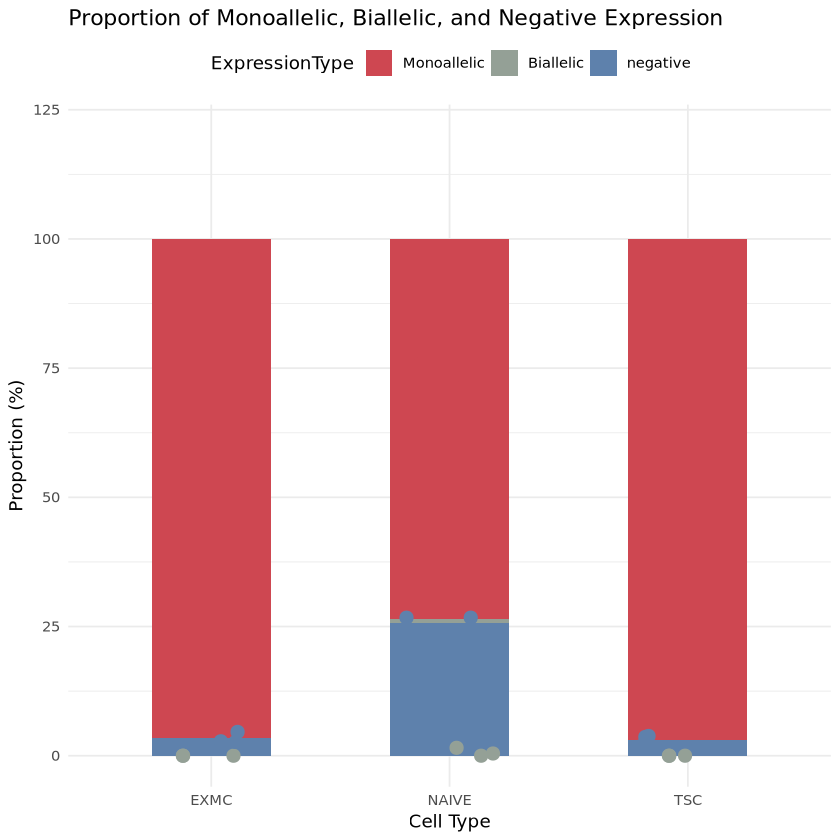

In [76]:
# Set desired stacking order BEFORE plotting
data_long$ExpressionType <- factor(data_long$ExpressionType,
                                   levels = c("Monoallelic", "Biallelic", "negative"))

# Then replot
p_XIST <- ggplot(data_long, aes(x = Cell_type, y = Proportion, fill = ExpressionType)) +
  geom_bar(stat = "summary", fun = "mean", position = "stack", width = 0.5) +
  geom_point(aes(color = ExpressionType),
             position = position_jitter(width = 0.2), size = 2, shape = 21, stroke = 1.5) +
  labs(title = "Proportion of Monoallelic, Biallelic, and Negative Expression",
       x = "Cell Type", y = "Proportion (%)") +
  scale_fill_manual(values = c("Monoallelic" = mono_color,
                               "Biallelic" = bi_color,
                               "negative" = neg_color)) +
  scale_color_manual(values = c("Monoallelic" = mono_color,
                                "Biallelic" = bi_color,
                                "negative" = neg_color)) +
  theme_minimal() +
  theme(legend.position = "top") +
  stat_compare_means(aes(group = ExpressionBinary), 
                     method = "wilcox.test", 
                     label = "p.signif", 
                     label.y = 120, 
                     hide.ns = TRUE)

p_XIST


In [77]:
# Define comparisons
my_comparisons <- list(c("NAIVE", "EXMC"), c("NAIVE", "TSC"))

Warning message in wilcox.test.default(c(1.526717557, 71.75572519, 26.71755725, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(1.526717557, 71.75572519, 26.71755725, :
“cannot compute exact p-value with ties”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range (`geom_point()`).”


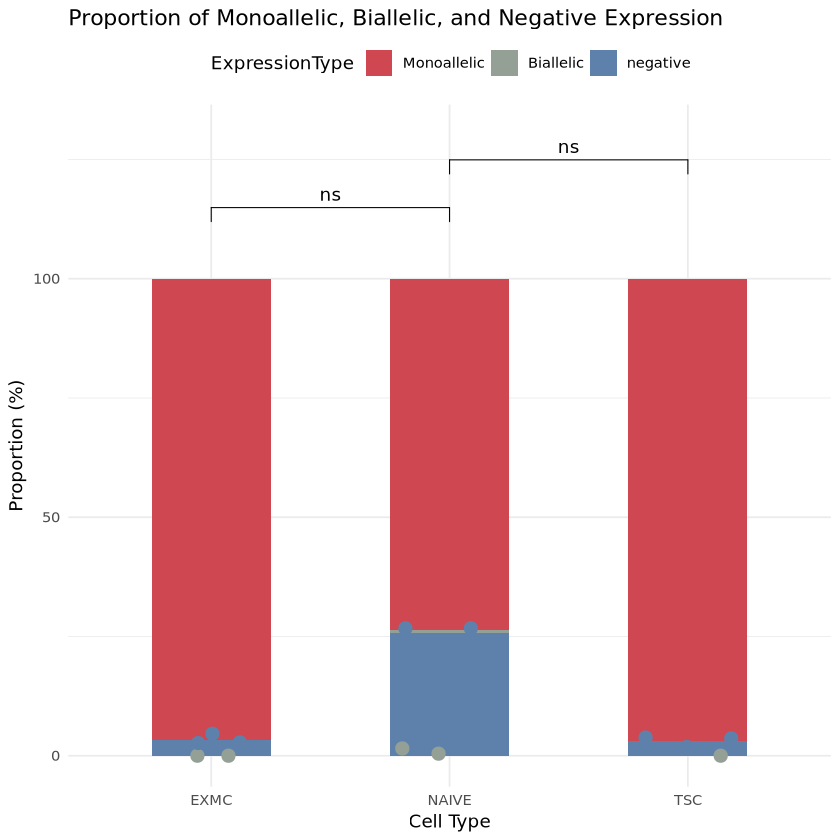

In [78]:
# Ensure correct stacking order
data_long$ExpressionType <- factor(data_long$ExpressionType,
                                   levels = c("Monoallelic", "Biallelic", "negative"))

# Plot
p_XIST <- ggplot(data_long, aes(x = Cell_type, y = Proportion, fill = ExpressionType)) +
  geom_bar(stat = "summary", fun = "mean", position = "stack", width = 0.5) +
  geom_point(aes(color = ExpressionType),
             position = position_jitter(width = 0.2), size = 2, shape = 21, stroke = 1.5) +
  scale_fill_manual(values = c("Monoallelic" = mono_color,
                               "Biallelic" = bi_color,
                               "negative" = neg_color)) +
  scale_color_manual(values = c("Monoallelic" = mono_color,
                                "Biallelic" = bi_color,
                                "negative" = neg_color)) +
  labs(title = "Proportion of Monoallelic, Biallelic, and Negative Expression",
       x = "Cell Type", y = "Proportion (%)") +
  theme_minimal() +
  theme(legend.position = "top") +
  stat_compare_means(comparisons = my_comparisons,
                     method = "wilcox.test",
                     aes(group = Cell_type),
                     label = "p.signif",
                     label.y = c(110, 120)) +  # Adjust for visibility
  ylim(0, 130)

p_XIST

In [79]:
output_path <- "/lustre1/project/stg_00041/Amitesh/FISH_quantification_random/"
filename <- "XIST_with_negative cells_with_individual_experiments.pdf"

In [80]:
ggsave(file.path(output_path, filename), plot = p_THOC2, height = 8, width = 8)

Warning message in wilcox.test.default(c(1.526717557, 71.75572519, 26.71755725, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(1.526717557, 71.75572519, 26.71755725, :
“cannot compute exact p-value with ties”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range (`geom_point()`).”


## For fig 3 we have performed H2AK119UB togetehr with RNA POL2 DYNAMICS

In [15]:
data_pol2 <- data.frame(
     Experiment = c('EXP1', 'EXP1', 'EXP1', 'EXP1', 'EXP1', 'EXP1', 'EXP1', 'EXP2', 'EXP2', 'EXP2', 'EXP2', 'EXP2', 'EXP2', 'EXP2'),
    Cell_type = c('D0', 'D4', 'D8', 'D10', 'D12', 'D14', 'D16', 'D0', 'D4', 'D8', 'D10', 'D12', 'D14', 'D16'),
  exclusion = c(3, 16, NA, 42, NA, 45, 80, 19.5122, 31.3752, 67.3913, 66.9014, 61.6, 75, 80),
  noexclusion = c(97,84, NA, 58, NA, 55, 20, 80.4878, 68.6275, 32.6087, 33.098, 38.4, 25, 20)
    )
# Reshape data to long format
library(tidyr)
data_long_pol2 <- data_pol2 %>%
  pivot_longer(cols = c("exclusion", "noexclusion"), names_to = "ExpressionType", values_to = "Proportion")

In [6]:
dim(data_long_pol2)
head(data_long_pol2, 50)

[1] 28  4

Experiment,Cell_type,ExpressionType,Proportion
<chr>,<chr>,<chr>,<dbl>
EXP1,D0,exclusion,3.0000
EXP1,D0,noexclusion,97.0000
EXP1,D4,exclusion,16.0000
EXP1,D4,noexclusion,84.0000
EXP1,D8,exclusion,NA
EXP1,D8,noexclusion,NA
EXP1,D10,exclusion,42.0000
EXP1,D10,noexclusion,58.0000
EXP1,D12,exclusion,NA


In [7]:
# Set factor levels for Cell_type in the desired order
data_long_pol2$Cell_type <- factor(data_long_pol2$Cell_type, levels = c("D0", "D4", "D8", "D10", "D12", "D14", "D16"))

Warning message:
“Removed 4 rows containing non-finite outside the scale range (`stat_summary()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range (`geom_point()`).”


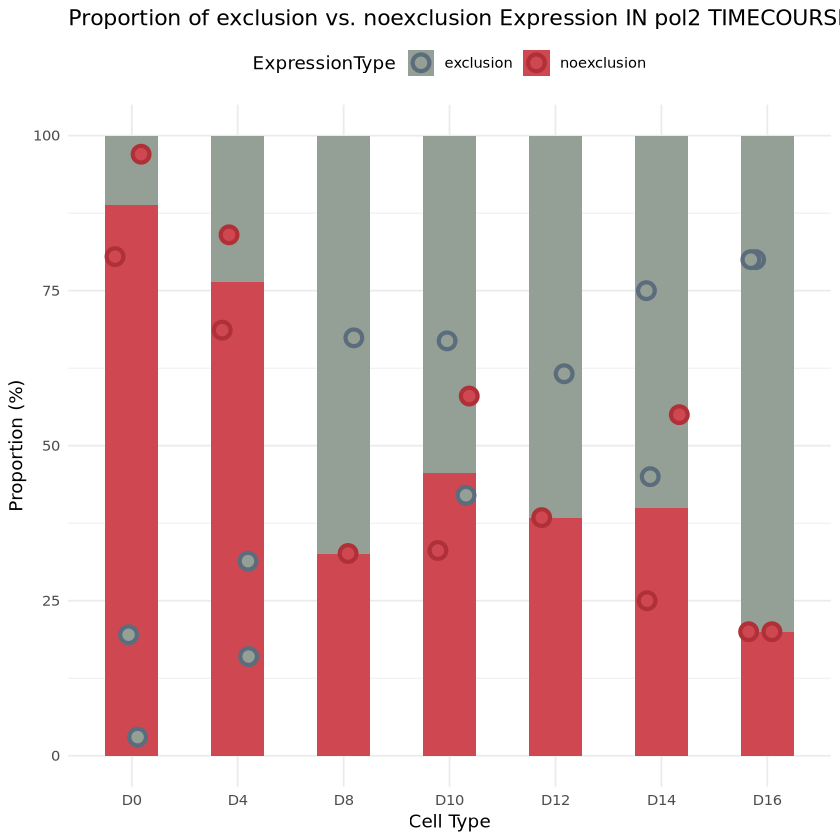

In [11]:
# Custom color palette for bars
exclusion <- "#94a096"
no_exclusion <- "#ce4751"

# New color palette for dots (distinct but corresponding)
exclusion_dot_color <- "#5b6d7c"  # Darker shade of bi_color
noexclusion_dot_color <- "#b03038"  # Darker shade of mono_color

# Plot with stacked bars and bold dots for individual experiments
p_pol2 <- ggplot(data_long_pol2, aes(x = Cell_type, y = Proportion, fill = ExpressionType)) +
  geom_bar(stat = "summary", fun = "mean", position = "stack", width = 0.5) +  # Bars remain the same
  geom_point(aes(x = Cell_type, y = Proportion, color = ExpressionType),  # Different colors for dots
             position = position_jitter(width = 0.2, height = 0), 
             size = 3.5, shape = 21, stroke = 1.8) +  # Bold dots with larger size and stroke
  labs(title = "Proportion of exclusion vs. noexclusion Expression IN pol2 TIMECOURSE",
       x = "Cell Type",
       y = "Proportion (%)") +
  scale_fill_manual(values = c("exclusion" = exclusion, "noexclusion" = no_exclusion)) +  # Keep bar colors
  scale_color_manual(values = c("exclusion" = exclusion_dot_color, "noexclusion" = noexclusion_dot_color)) +  # Different dot colors
  theme_minimal() +
  theme(legend.position = "top")

p_pol2

In [12]:
output_path <- "/lustre1/project/stg_00041/Amitesh/FISH_quantification_random/"
filename <- "pol2_TIMECOURSE_with_individual_experiments.pdf"

In [13]:
ggsave(file.path(output_path, filename), plot = p_pol2, height = 8, width = 8)

Warning message:
“Removed 4 rows containing non-finite outside the scale range (`stat_summary()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range (`geom_point()`).”


## H2AK119UB RNA POL2 DYNAMICS only in GATA3+ CELLS

In [17]:
# Example data
data_pol2_GATA3 <- data.frame(
     Experiment = c('EXP1', 'EXP1', 'EXP1', 'EXP1', 'EXP1', 'EXP1', 'EXP1', 'EXP2', 'EXP2', 'EXP2', 'EXP2', 'EXP2', 'EXP2', 'EXP2'),
    Cell_type = c('D0', 'D4', 'D8', 'D10', 'D12', 'D14', 'D16', 'D0', 'D4', 'D8', 'D10', 'D12', 'D14', 'D16'),
  exclusion = c(NA, 24, NA, 57, 67, 82, 85, NA, 33.333, 67.3913, 68.80734, 65.78947, 81.15942, 78.04878),
  noexclusion = c(NA,76, NA, 43, 33, 18, 15, NA, 67.666, 32.6087, 31.19266, 34.21053, 18.84058, 21.95122)
    )
# Reshape data to long format
library(tidyr)
data_long_pol2_GATA3 <- data_pol2_GATA3 %>%
  pivot_longer(cols = c("exclusion", "noexclusion"), names_to = "ExpressionType", values_to = "Proportion")

In [18]:
#view(data_long_GAT3_POLA1)
#tail(data_long_GAT3_POLA1)
dim(data_long_pol2_GATA3)
head(data_long_pol2_GATA3, 50)

[1] 28  4

Experiment,Cell_type,ExpressionType,Proportion
<chr>,<chr>,<chr>,<dbl>
EXP1,D0,exclusion,NA
EXP1,D0,noexclusion,NA
EXP1,D4,exclusion,24.00000
EXP1,D4,noexclusion,76.00000
EXP1,D8,exclusion,NA
EXP1,D8,noexclusion,NA
EXP1,D10,exclusion,57.00000
EXP1,D10,noexclusion,43.00000
EXP1,D12,exclusion,67.00000


In [19]:
# Set factor levels for Cell_type in the desired order
data_long_pol2_GATA3$Cell_type <- factor(data_long_pol2_GATA3$Cell_type, levels = c("D0", "D4", "D8", "D10", "D12", "D14", "D16"))

Warning message:
“Removed 6 rows containing non-finite outside the scale range (`stat_summary()`).”
Warning message:
“Removed 6 rows containing missing values or values outside the scale range (`geom_point()`).”


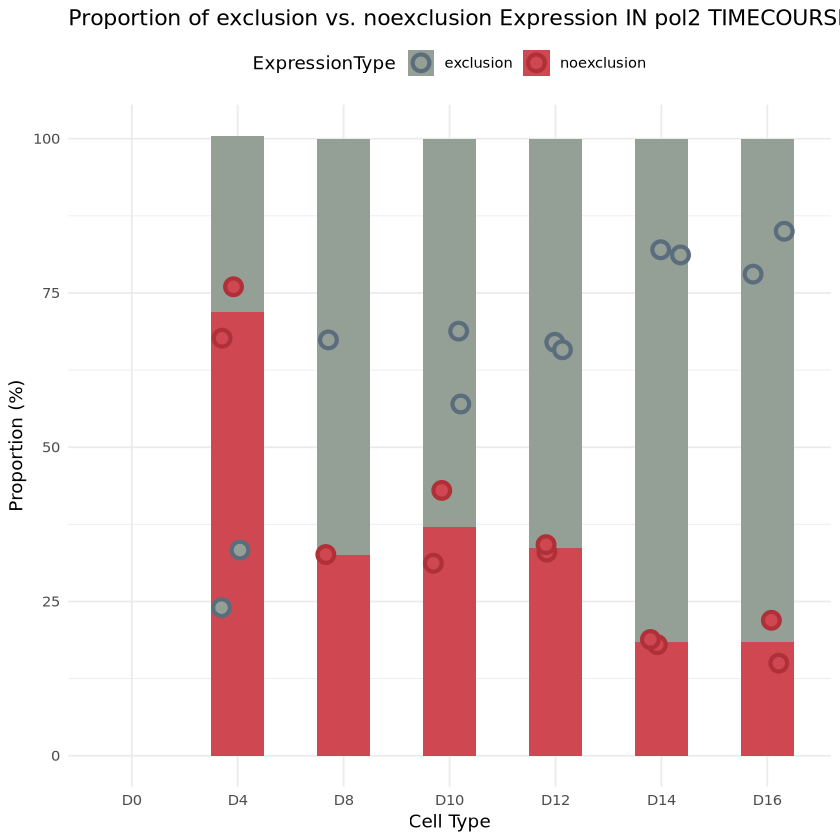

In [20]:
# Load necessary libraries
library(ggplot2)

# Custom color palette for bars
exclusion <- "#94a096"
no_exclusion <- "#ce4751"

# New color palette for dots (distinct but corresponding)
exclusion_dot_color <- "#5b6d7c"  # Darker shade of bi_color
noexclusion_dot_color <- "#b03038"  # Darker shade of mono_color

# Plot with stacked bars and bold dots for individual experiments
p_pol2_gata3 <- ggplot(data_long_pol2_GATA3, aes(x = Cell_type, y = Proportion, fill = ExpressionType)) +
  geom_bar(stat = "summary", fun = "mean", position = "stack", width = 0.5) +  # Bars remain the same
  geom_point(aes(x = Cell_type, y = Proportion, color = ExpressionType),  # Different colors for dots
             position = position_jitter(width = 0.2, height = 0), 
             size = 3.5, shape = 21, stroke = 1.8) +  # Bold dots with larger size and stroke
  labs(title = "Proportion of exclusion vs. noexclusion Expression IN pol2 TIMECOURSE with GATA3 positive cells",
       x = "Cell Type",
       y = "Proportion (%)") +
  scale_fill_manual(values = c("exclusion" = exclusion, "noexclusion" = no_exclusion)) +  # Keep bar colors
  scale_color_manual(values = c("exclusion" = exclusion_dot_color, "noexclusion" = noexclusion_dot_color)) +  # Different dot colors
  theme_minimal() +
  theme(legend.position = "top")

p_pol2_gata3

In [21]:
output_path <- "/lustre1/project/stg_00041/Amitesh/FISH_quantification_random/"
filename <- "pol2_TIMECOURSE_with_GATA3_individual_experiments.pdf"

In [22]:
ggsave(file.path(output_path, filename), plot = p_pol2_gata3, height = 8, width = 8)

Warning message:
“Removed 6 rows containing non-finite outside the scale range (`stat_summary()`).”
Warning message:
“Removed 6 rows containing missing values or values outside the scale range (`geom_point()`).”


## H2AK119UB RNA POL2 DYNAMICS only in GATA6+ CELLS

In [23]:
# Example data
data_pol2_GATA6 <- data.frame(
     Experiment = c('EXP1', 'EXP1', 'EXP1', 'EXP1', 'EXP1', 'EXP1', 'EXP1', 'EXP2', 'EXP2', 'EXP2', 'EXP2', 'EXP2', 'EXP2', 'EXP2'),
    Cell_type = c('D0', 'D4', 'D8', 'D10', 'D12', 'D14', 'D16', 'D0', 'D4', 'D8', 'D10', 'D12', 'D14', 'D16'),
  exclusion = c(NA, 31, NA, 71, 74, 82, 63, NA, 31.3725, 59.2593, 63.2653, 55.102, 66.6667, 80),
  noexclusion = c(NA,69, NA, 29, 26, 18, 37, NA, 68.6275, 40.7404, 36.7347, 44.898, 33.3333, 20)
    )
# Reshape data to long format
library(tidyr)
data_long_pol2_GATA6 <- data_pol2_GATA6 %>%
  pivot_longer(cols = c("exclusion", "noexclusion"), names_to = "ExpressionType", values_to = "Proportion")

In [24]:
#view(data_long_GAT3_POLA1)
#tail(data_long_GAT3_POLA1)
dim(data_long_pol2_GATA6)
head(data_long_pol2_GATA6, 50)

[1] 28  4

Experiment,Cell_type,ExpressionType,Proportion
<chr>,<chr>,<chr>,<dbl>
EXP1,D0,exclusion,NA
EXP1,D0,noexclusion,NA
EXP1,D4,exclusion,31.0000
EXP1,D4,noexclusion,69.0000
EXP1,D8,exclusion,NA
EXP1,D8,noexclusion,NA
EXP1,D10,exclusion,71.0000
EXP1,D10,noexclusion,29.0000
EXP1,D12,exclusion,74.0000


In [25]:
# Set factor levels for Cell_type in the desired order
data_long_pol2_GATA6$Cell_type <- factor(data_long_pol2_GATA6$Cell_type, levels = c("D0", "D4", "D8", "D10", "D12", "D14", "D16"))

Warning message:
“Removed 6 rows containing non-finite outside the scale range (`stat_summary()`).”
Warning message:
“Removed 6 rows containing missing values or values outside the scale range (`geom_point()`).”


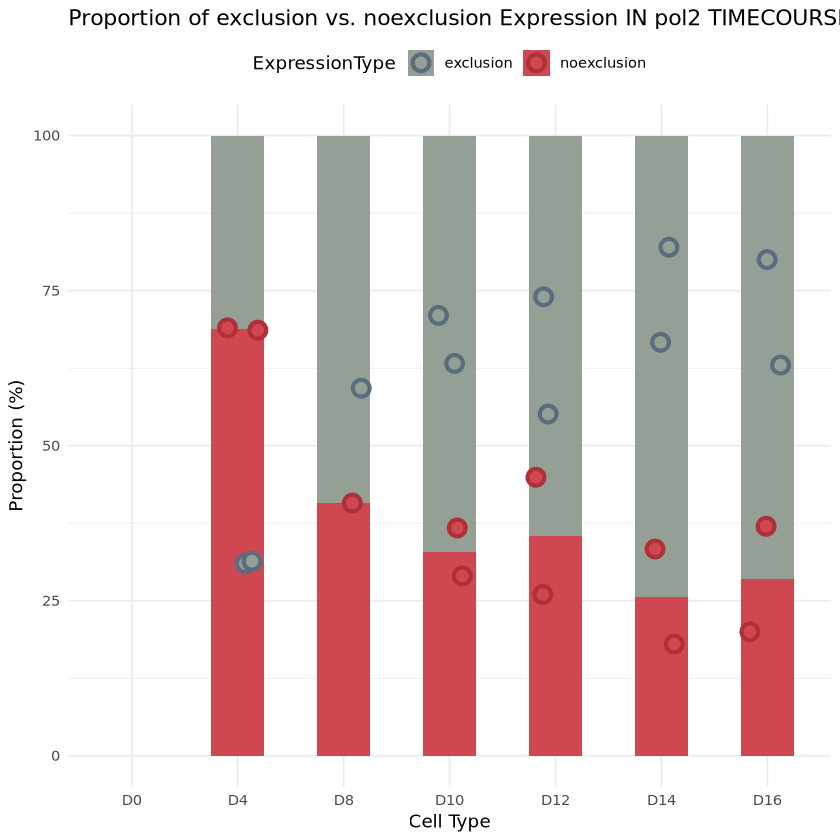

In [26]:
# Load necessary libraries
library(ggplot2)

# Custom color palette for bars
exclusion <- "#94a096"
no_exclusion <- "#ce4751"

# New color palette for dots (distinct but corresponding)
exclusion_dot_color <- "#5b6d7c"  # Darker shade of bi_color
noexclusion_dot_color <- "#b03038"  # Darker shade of mono_color

# Plot with stacked bars and bold dots for individual experiments
p_pol2_gata6 <- ggplot(data_long_pol2_GATA6, aes(x = Cell_type, y = Proportion, fill = ExpressionType)) +
  geom_bar(stat = "summary", fun = "mean", position = "stack", width = 0.5) +  # Bars remain the same
  geom_point(aes(x = Cell_type, y = Proportion, color = ExpressionType),  # Different colors for dots
             position = position_jitter(width = 0.2, height = 0), 
             size = 3.5, shape = 21, stroke = 1.8) +  # Bold dots with larger size and stroke
  labs(title = "Proportion of exclusion vs. noexclusion Expression IN pol2 TIMECOURSE with GATA6 positive cells",
       x = "Cell Type",
       y = "Proportion (%)") +
  scale_fill_manual(values = c("exclusion" = exclusion, "noexclusion" = no_exclusion)) +  # Keep bar colors
  scale_color_manual(values = c("exclusion" = exclusion_dot_color, "noexclusion" = noexclusion_dot_color)) +  # Different dot colors
  theme_minimal() +
  theme(legend.position = "top")

p_pol2_gata6

In [27]:
output_path <- "/lustre1/project/stg_00041/Amitesh/FISH_quantification_random/"
filename <- "pol2_TIMECOURSE_with_GATA6_individual_experiments.pdf"

In [28]:
ggsave(file.path(output_path, filename), plot = p_pol2_gata6, height = 8, width = 8)

Warning message:
“Removed 6 rows containing non-finite outside the scale range (`stat_summary()`).”
Warning message:
“Removed 6 rows containing missing values or values outside the scale range (`geom_point()`).”


## Perform logistic regression on the pol2 timecourse

In [1]:
library(ggplot2)
library(dplyr)
library(tidyr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
library(readxl)
library(broom) 

In [37]:
data_pol2_mixed <- read.xlsx("/lustre1/project/stg_00041/Amitesh/STST_POL2_DYNAMICS/MIXED_POL2.xlsx")

In [38]:
data_pol2_mixed

,EXP,DAY,Exclusion,Noexclusion
,<dbl>,<chr>,<dbl>,<dbl>
1,1,D0,3,84
2,2,D0,8,33
3,1,D4,25,135
4,2,D4,16,35
5,1,D8,NA,NA
6,2,D8,63,37
7,1,D10,29,40
8,2,D10,95,47
9,1,D12,NA,NA


In [40]:
alpha <- 0.01
data_long <- data_pol2_mixed %>%
  select(EXP, DAY, Exclusion, Noexclusion) %>%
  pivot_longer(cols = c(Exclusion, Noexclusion), 
               names_to = "Type", 
               values_to = "Count") %>%
  mutate(Expression_type = ifelse(Type == "Noexclusion", 1, 0))

head(data_long)

EXP,DAY,Type,Count,Expression_type
<dbl>,<chr>,<chr>,<dbl>,<dbl>
1,D0,Exclusion,3,0
1,D0,Noexclusion,84,1
2,D0,Exclusion,8,0
2,D0,Noexclusion,33,1
1,D4,Exclusion,25,0
1,D4,Noexclusion,135,1


In [42]:
#Take D4, D10,D14
data_long$DAY <- factor(data_long$DAY)#relevel will only work on DAY if it is a factor
data_long$DAY <- relevel(data_long$DAY, ref = "D16")
Tc_model <- glm(Expression_type ~ DAY + factor(EXP),
                  data = data_long,
                  weights = Count,  # Using Count as weights
                  family = binomial)

summary(Tc_model) #returns results at alpha 0.05


Call:
glm(formula = Expression_type ~ DAY + factor(EXP), family = binomial, 
    data = data_long, weights = Count)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept)   -1.0279     0.2531  -4.061 4.88e-05 ***
DAYD10         1.3391     0.2941   4.554 5.27e-06 ***
DAYD0          3.8126     0.4060   9.391  < 2e-16 ***
DAYD12         1.5646     0.3335   4.691 2.72e-06 ***
DAYD14         1.0400     0.3044   3.417 0.000634 ***
DAYD4          2.7511     0.3052   9.013  < 2e-16 ***
DAYD8          1.5050     0.3469   4.339 1.43e-05 ***
factor(EXP)2  -1.0093     0.1754  -5.753 8.78e-09 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1459.2  on 23  degrees of freedom
Residual deviance: 1160.8  on 16  degrees of freedom
  (4 observations deleted due to missingness)
AIC: 1176.8

Number of Fisher Scoring iterations: 5


In [43]:
Tc_model_summary <- summary(Tc_model) #and save to variable
p_values <- coef(Tc_model_summary)[, "Pr(>|z|)"]
print(p_values)

 (Intercept)       DAYD10        DAYD0       DAYD12       DAYD14        DAYD4 
4.876258e-05 5.266925e-06 5.970534e-21 2.718414e-06 6.336772e-04 2.011176e-19 
       DAYD8 factor(EXP)2 
1.433249e-05 8.779180e-09 


In [44]:
Tc_model_results <- broom::tidy(Tc_model) %>% 
  mutate(Significant = p.value < alpha)

print(Tc_model_results) #returns results at alpha 0.01

install.packages("emmeans")
library(emmeans)
pairwise_comparisons <- emmeans(Tc_model, pairwise ~ DAY, type = "response")
summary(pairwise_comparisons$contrasts)
summary(pairwise_comparisons$contrasts, adjust = "bonferroni")


# A tibble: 8 × 6
  term         estimate std.error statistic  p.value Significant
  <chr>           <dbl>     <dbl>     <dbl>    <dbl> <lgl>      
1 (Intercept)     -1.03     0.253     -4.06 4.88e- 5 TRUE       
2 DAYD10           1.34     0.294      4.55 5.27e- 6 TRUE       
3 DAYD0            3.81     0.406      9.39 5.97e-21 TRUE       
4 DAYD12           1.56     0.334      4.69 2.72e- 6 TRUE       
5 DAYD14           1.04     0.304      3.42 6.34e- 4 TRUE       
6 DAYD4            2.75     0.305      9.01 2.01e-19 TRUE       
7 DAYD8            1.50     0.347      4.34 1.43e- 5 TRUE       
8 factor(EXP)2    -1.01     0.175     -5.75 8.78e- 9 TRUE       


also installing the dependency ‘estimability’


Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'



,contrast,odds.ratio,SE,df,null,z.ratio,p.value
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,D16 / D10,0.26209009,0.077067768,Inf,1,-4.5538646,1.073418e-04
2,D16 / D0,0.02209165,0.008969221,Inf,1,-9.3905190,6.605827e-14
3,D16 / D12,0.20916933,0.069764872,Inf,1,-4.6910237,5.574468e-05
4,D16 / D14,0.35344253,0.107584616,Inf,1,-3.4167746,1.131190e-02
5,D16 / D4,0.06385804,0.019492513,Inf,1,-9.0126602,4.651834e-14
6,D16 / D8,0.22201757,0.077012883,Inf,1,-4.3387048,2.884649e-04
7,D10 / D0,0.08429028,0.029540636,Inf,1,-7.0577715,3.557343e-11
8,D10 / D12,0.79808179,0.192602685,Inf,1,-0.9345805,9.670330e-01
9,D10 / D14,1.34855359,0.294865769,Inf,1,1.3676104,8.191733e-01


,contrast,odds.ratio,SE,df,null,z.ratio,p.value
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,D16 / D10,0.26209009,0.077067768,Inf,1,-4.5538646,1.106054e-04
2,D16 / D0,0.02209165,0.008969221,Inf,1,-9.3905190,1.253812e-19
3,D16 / D12,0.20916933,0.069764872,Inf,1,-4.6910237,5.708670e-05
4,D16 / D14,0.35344253,0.107584616,Inf,1,-3.4167746,1.330722e-02
5,D16 / D4,0.06385804,0.019492513,Inf,1,-9.0126602,4.223470e-18
6,D16 / D8,0.22201757,0.077012883,Inf,1,-4.3387048,3.009823e-04
7,D10 / D0,0.08429028,0.029540636,Inf,1,-7.0577715,3.553074e-11
8,D10 / D12,0.79808179,0.192602685,Inf,1,-0.9345805,1.000000e+00
9,D10 / D14,1.34855359,0.294865769,Inf,1,1.3676104,1.000000e+00


In [45]:
output_dir <- "/lustre1/project/stg_00041/Amitesh/STST_POL2_DYNAMICS/"

In [49]:
write_xlsx(Tc_model_results, file.path(output_dir, "Tc_model_results_mixed_pol2_dynamics.xlsx"))

pairwise_df <- summary(pairwise_comparisons$contrasts, adjust = "bonferroni") %>% as.data.frame()
write_xlsx(pairwise_df, file.path(output_dir, "pairwise_comparisons_bonferroni_mixed_pol2_dynamics.xlsx"))

In [48]:
install.packages("writexl")


In [3]:
library(writexl)

## Perform logistic regression on the pol2 timecourse BUT IN gata3 POSITIVE CELLS

In [6]:
data_pol2_GATA3 <- read.xlsx("/lustre1/project/stg_00041/Amitesh/STST_POL2_DYNAMICS/GATA3_POL2.xlsx")

In [7]:
data_pol2_GATA3

,EXP,DAY,Exclusion,Noexclusion
,<dbl>,<chr>,<dbl>,<dbl>
1,1,D0,NA,NA
2,2,D0,NA,NA
3,1,D4,38,118
4,2,D4,5,10
5,1,D8,NA,NA
6,2,D8,31,15
7,1,D10,28,21
8,2,D10,75,34
9,1,D12,18,9


In [8]:
alpha <- 0.01
data_long_GATA3 <- data_pol2_GATA3 %>%
  select(EXP, DAY, Exclusion, Noexclusion) %>%
  pivot_longer(cols = c(Exclusion, Noexclusion), 
               names_to = "Type", 
               values_to = "Count") %>%
  mutate(Expression_type = ifelse(Type == "Noexclusion", 1, 0))

head(data_long_GATA3)

EXP,DAY,Type,Count,Expression_type
<dbl>,<chr>,<chr>,<dbl>,<dbl>
1,D0,Exclusion,NA,0
1,D0,Noexclusion,NA,1
2,D0,Exclusion,NA,0
2,D0,Noexclusion,NA,1
1,D4,Exclusion,38,0
1,D4,Noexclusion,118,1


In [10]:
#Take D4, D10,D14
data_long_GATA3$DAY <- factor(data_long_GATA3$DAY)#relevel will only work on DAY if it is a factor
data_long_GATA3$DAY <- relevel(data_long_GATA3$DAY, ref = "D16")
Tc_model_GATA3 <- glm(Expression_type ~ DAY + factor(EXP),
                  data = data_long_GATA3,
                  weights = Count,  # Using Count as weights
                  family = binomial)

summary(Tc_model_GATA3) #returns results at alpha 0.05


Call:
glm(formula = Expression_type ~ DAY + factor(EXP), family = binomial, 
    data = data_long_GATA3, weights = Count)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept)  -1.45750    0.27313  -5.336 9.49e-08 ***
DAYD10        0.93127    0.31564   2.950  0.00317 ** 
DAYD12        0.90162    0.34120   2.642  0.00823 ** 
DAYD14        0.08147    0.36852   0.221  0.82503    
DAYD4         2.56171    0.32061   7.990 1.35e-15 ***
DAYD8         0.87920    0.42866   2.051  0.04026 *  
factor(EXP)2 -0.14764    0.21292  -0.693  0.48805    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 913.65  on 21  degrees of freedom
Residual deviance: 779.08  on 15  degrees of freedom
  (6 observations deleted due to missingness)
AIC: 793.08

Number of Fisher Scoring iterations: 5


In [11]:
Tc_model_summary_GATA3 <- summary(Tc_model_GATA3) #and save to variable
p_values_GATA3 <- coef(Tc_model_summary_GATA3)[, "Pr(>|z|)"]
print(p_values_GATA3)

 (Intercept)       DAYD10       DAYD12       DAYD14        DAYD4        DAYD8 
9.486371e-08 3.173141e-03 8.230362e-03 8.250306e-01 1.349104e-15 4.026299e-02 
factor(EXP)2 
4.880499e-01 


In [12]:
Tc_model_results_GATA3 <- broom::tidy(Tc_model_GATA3) %>% 
  mutate(Significant = p.value < alpha)

print(Tc_model_results_GATA3) #returns results at alpha 0.01

library(emmeans)
pairwise_comparisons_GATA3 <- emmeans(Tc_model_GATA3, pairwise ~ DAY, type = "response")
summary(pairwise_comparisons_GATA3$contrasts)
summary(pairwise_comparisons_GATA3$contrasts, adjust = "bonferroni")

# A tibble: 7 × 6
  term         estimate std.error statistic  p.value Significant
  <chr>           <dbl>     <dbl>     <dbl>    <dbl> <lgl>      
1 (Intercept)   -1.46       0.273    -5.34  9.49e- 8 TRUE       
2 DAYD10         0.931      0.316     2.95  3.17e- 3 TRUE       
3 DAYD12         0.902      0.341     2.64  8.23e- 3 TRUE       
4 DAYD14         0.0815     0.369     0.221 8.25e- 1 FALSE      
5 DAYD4          2.56       0.321     7.99  1.35e-15 TRUE       
6 DAYD8          0.879      0.429     2.05  4.03e- 2 FALSE      
7 factor(EXP)2  -0.148      0.213    -0.693 4.88e- 1 FALSE      


Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'



,contrast,odds.ratio,SE,df,null,z.ratio,p.value
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,D16 / D10,0.39405489,0.12437760,Inf,1,-2.95044738,3.740193e-02
2,D16 / D12,0.40591105,0.13849843,Inf,1,-2.64247054,8.728279e-02
3,D16 / D14,0.92175774,0.33968892,Inf,1,-0.22107941,9.999280e-01
4,D16 / D4,0.07717283,0.02474263,Inf,1,-7.99002590,1.012523e-13
5,D16 / D8,0.41511298,0.17794344,Inf,1,-2.05104059,3.134343e-01
6,D10 / D12,1.03008759,0.27514376,Inf,1,0.11098107,9.999977e-01
7,D10 / D14,2.33916076,0.71210348,Inf,1,2.79144907,5.879948e-02
8,D10 / D4,0.19584285,0.05350039,Inf,1,-5.96837840,3.588353e-08
9,D10 / D8,1.05343947,0.38196488,Inf,1,0.14358017,9.999916e-01


,contrast,odds.ratio,SE,df,null,z.ratio,p.value
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,D16 / D10,0.39405489,0.12437760,Inf,1,-2.95044738,4.759711e-02
2,D16 / D12,0.40591105,0.13849843,Inf,1,-2.64247054,1.234554e-01
3,D16 / D14,0.92175774,0.33968892,Inf,1,-0.22107941,1.000000e+00
4,D16 / D4,0.07717283,0.02474263,Inf,1,-7.99002590,2.023656e-14
5,D16 / D8,0.41511298,0.17794344,Inf,1,-2.05104059,6.039449e-01
6,D10 / D12,1.03008759,0.27514376,Inf,1,0.11098107,1.000000e+00
7,D10 / D14,2.33916076,0.71210348,Inf,1,2.79144907,7.870892e-02
8,D10 / D4,0.19584285,0.05350039,Inf,1,-5.96837840,3.594347e-08
9,D10 / D8,1.05343947,0.38196488,Inf,1,0.14358017,1.000000e+00


In [13]:
output_dir <- "/lustre1/project/stg_00041/Amitesh/STST_POL2_DYNAMICS/"

In [15]:
write_xlsx(Tc_model_results_GATA3, file.path(output_dir, "Tc_model_results_GATA3_pol2_dynamics.xlsx"))

pairwise_df <- summary(pairwise_comparisons_GATA3$contrasts, adjust = "bonferroni") %>% as.data.frame()
write_xlsx(pairwise_df, file.path(output_dir, "pairwise_comparisons_bonferroni_GATA3_pol2_dynamics.xlsx"))